In [2]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm
from scipy.ndimage import gaussian_filter

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding
Thesis plot settings applied


C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\2525763464.py:18: UserWarning: The following kwargs were not used by contour: 'aspect'
  ax[0].contourf(z_nd, r_nd, u[750,:,:], cmap = 'bwr', norm = norm, aspect = 'fixed')


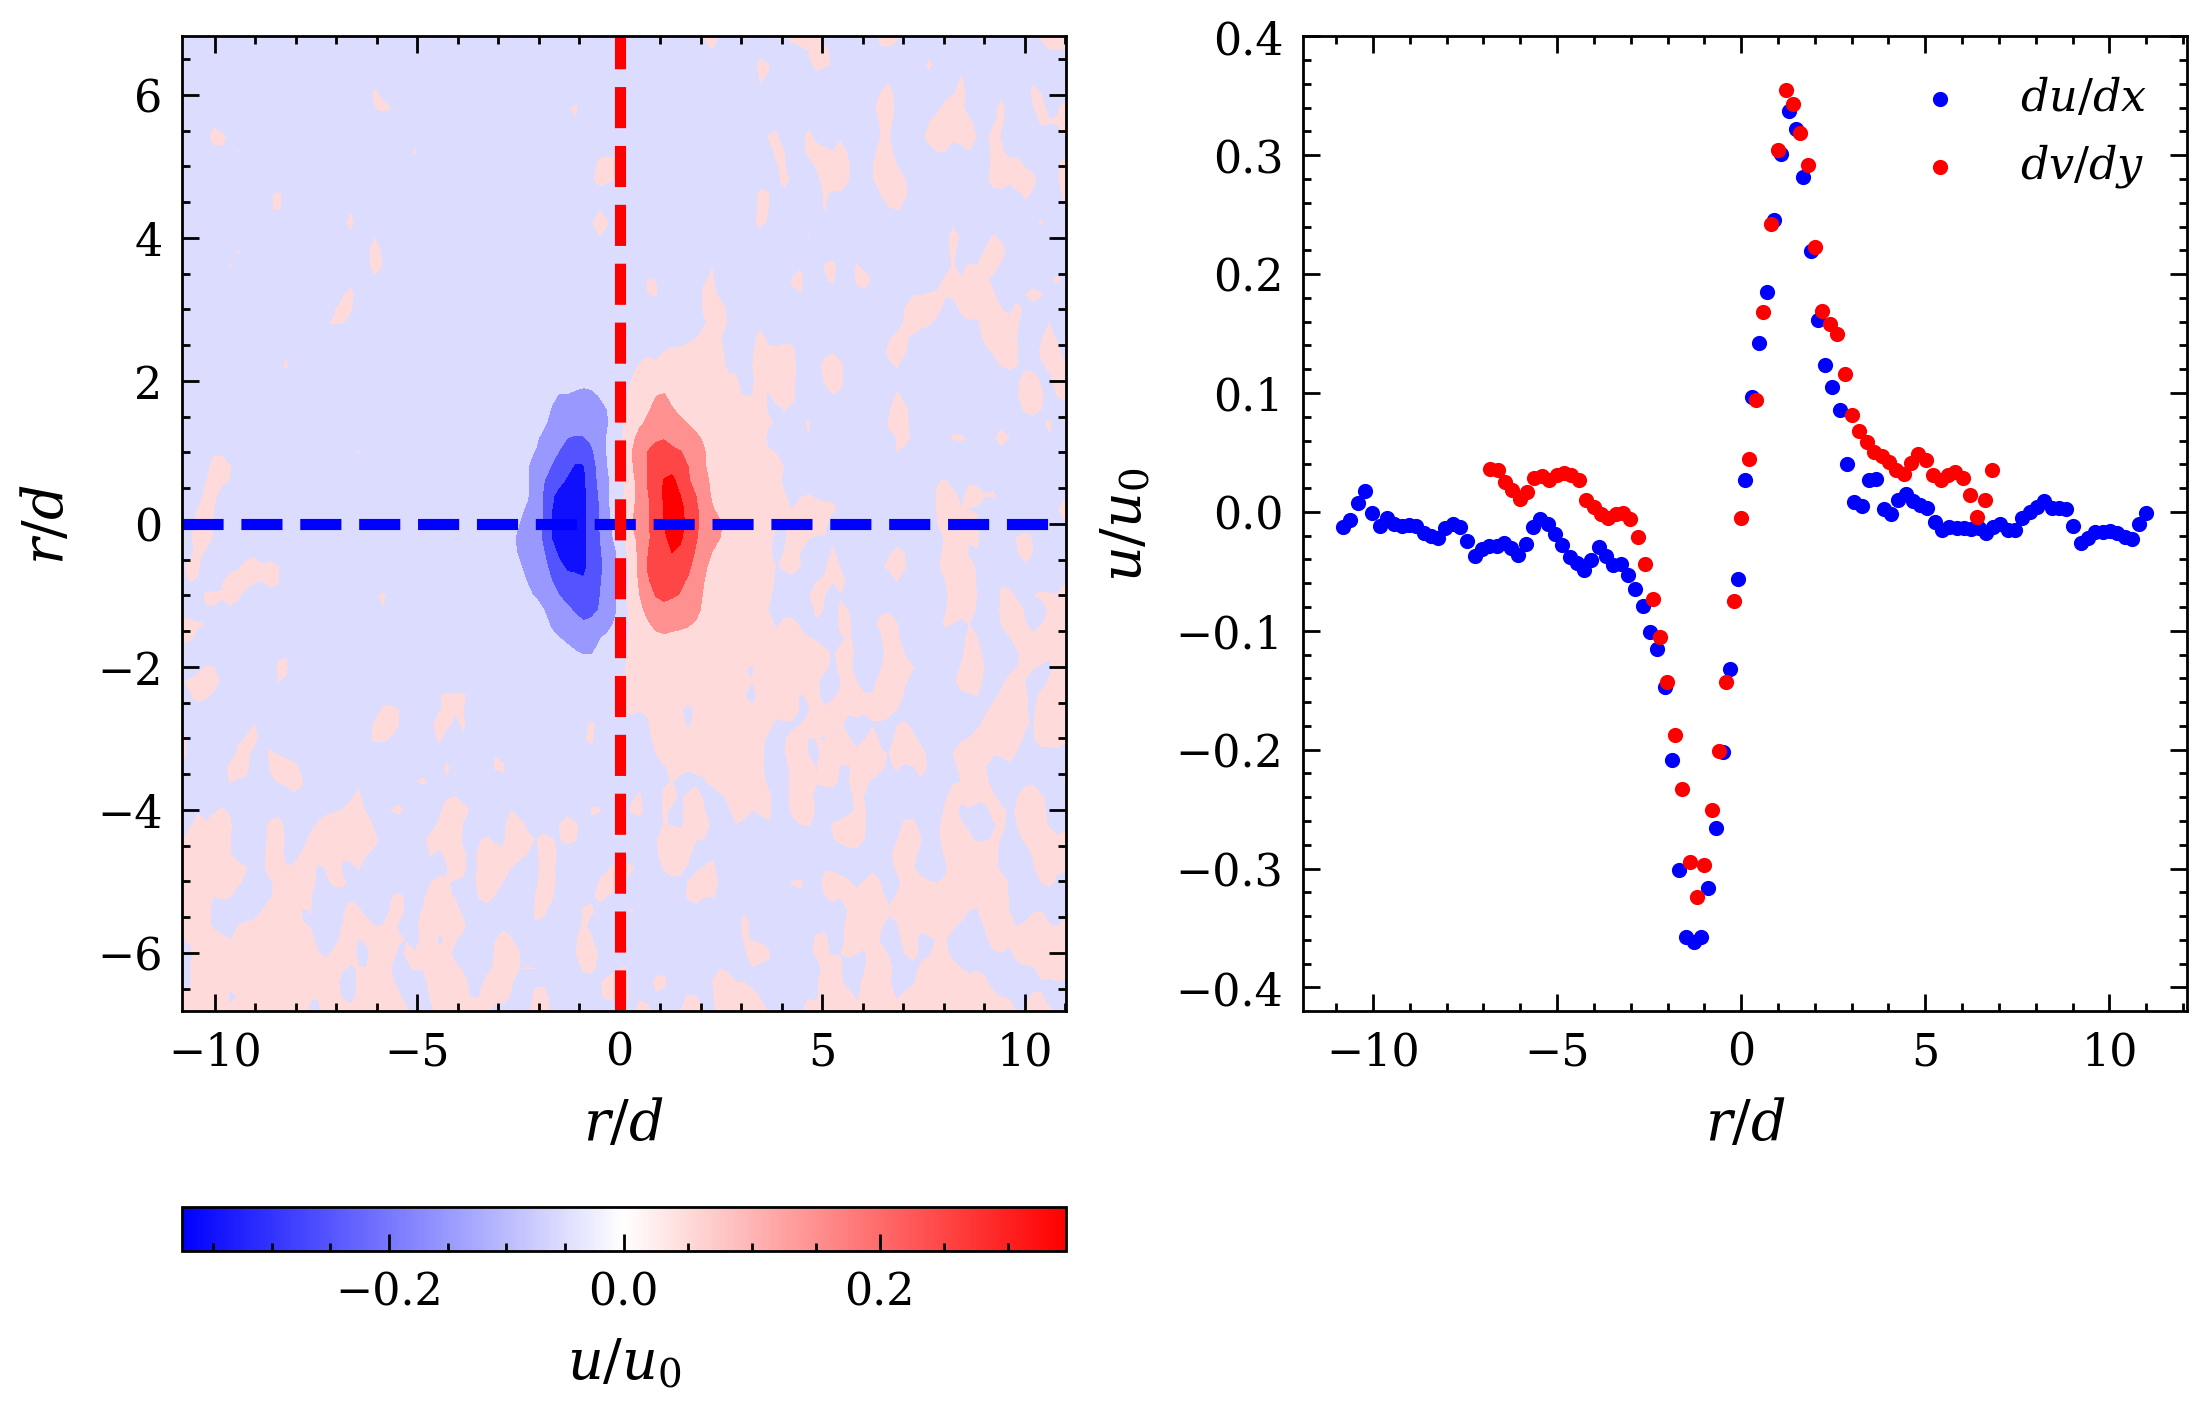

In [3]:
# h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')


vels = h5file['3D0']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])
frames0 = [750, 1020, 1470]

# u, v = gaussian_filter(u, 1), gaussian_filter(v, 1)

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])

norm = colors.TwoSlopeNorm(vmin=np.min(u[750,:,:]), vcenter=0, vmax=np.max(u[750,:,:]))
fig, ax = plt.subplots(1, 2,figsize=(5.5, 3.5), dpi = 400)
ax[0].contourf(z_nd, r_nd, u[750,:,:], cmap = 'bwr', norm = norm, aspect = 'fixed')
ax[0].hlines(y=0, xmin=z_nd[0], xmax=z_nd[-1], color='b', linestyle='--', )
ax[0].vlines(x=0, ymin=r_nd[0], ymax=r_nd[-1], color='r', linestyle='--', )
ax[0].set_xlabel('$r/d$')
ax[0].set_ylabel('$r/d$')
fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax[0], label=r'$u/u_{0}$', location='bottom')
ax[1].scatter(z_nd, u[750, int(u.shape[1]/2), :], label=r'$du/dx$', s=3, color='b')
ax[1].scatter(r_nd, v[750, :, int(u.shape[2]/2)], label=r'$dv/dy$', s=3, color='r')
ax[1].set_xlabel('$r/d$')
ax[1].set_ylabel(r'$u/u_{0}$')
ax[1].set_ylim(-0.42, 0.4)
plt.legend(fontsize=8)



now doing the wrap up

inds shape (7659,)
p shape (7659,)
r2 shape (7659,)
U_az2 shape (7659,)


C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\661642683.py:27: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\661642683.py:29: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\661642683.py:27: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\661642683.py:29: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\661642683.py:27: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipyk

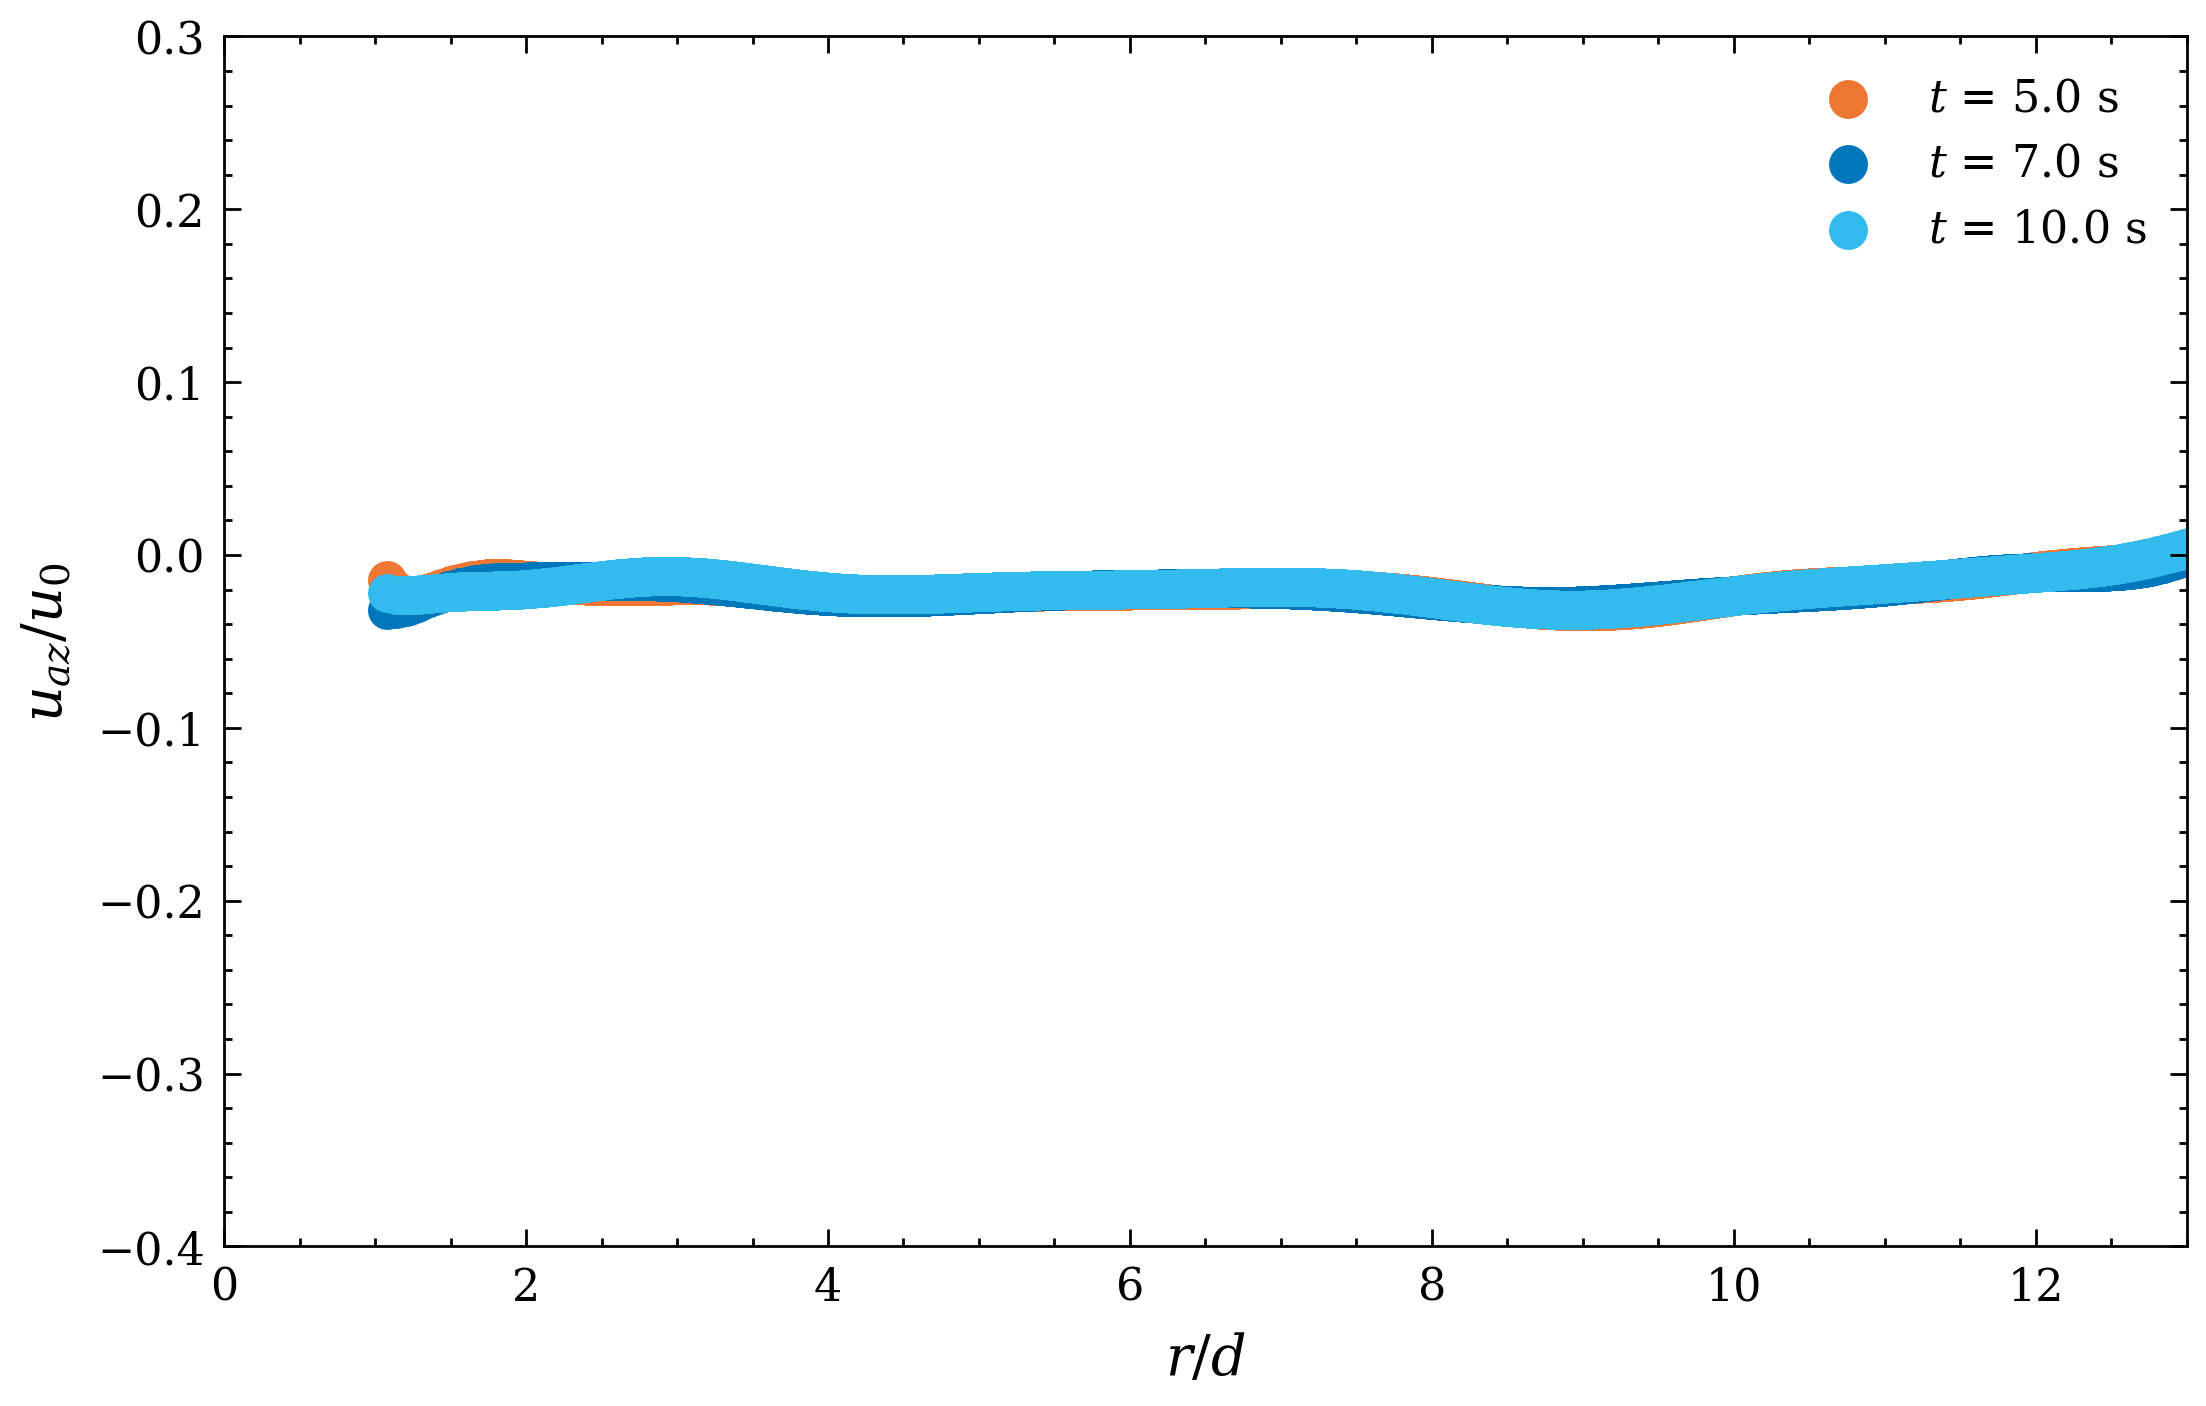

In [4]:
x_c = u.shape[2]/2
y_c = u.shape[1]/2
r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(x_c, y_c, x, y, u[750,:,:], v[750,:,:])
r_arr, theta_arr, U_rBins, U_azBins = oj.binCylindrical(r, theta, U_r, U_az, thetaBins=30, rBins=30)
inds = (r.flatten()).argsort()
r2 = (r.flatten())[inds]
U_az2 = (U_az.flatten())[inds]
p = np.poly1d(np.polyfit(r2, U_az2, 11))(r2)
max = np.argmax(p)

print('inds shape', inds.shape)
print('p shape', p.shape)
print('r2 shape', r2.shape)
print('U_az2 shape', U_az2.shape)

d=0.05
fig, ax = plt.subplots(1, figsize=(5.5, 3.5), dpi = 400)
frames = [750, 1020, 1470]
times = [750/150, 1050/150, 1500/150]

for i in range(len(frames)):
    r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[frames[i],:,:], v[frames[i],:,:])
    r_arr, theta_arr, U_rBins, U_azBins = oj.binCylindrical(r, theta, U_r, U_az, thetaBins=30, rBins=100)
    inds = (r.flatten()).argsort()
    r2 = (r.flatten())[inds]
    U_r2 = (U_r.flatten())[inds]
    pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
    U_az2 = (U_az.flatten())[inds]
    paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)


# ax.plot(r_arr, np.mean(U_rBins, axis=1), label=r'$u_{r}$', color='b')
# ax.scatter(r/d, U_az, color='c', alpha=0.5, edgecolors="k")
# ax.plot(r2/d, p, color='orange')
# ax.plot(r2/d, pr, color='b')
    ax.scatter(r2*0.1, paz, label=fr'$t$ = {times[i]} s')
ax.set_ylim(-0.4, 0.3)
ax.set_xlim(0, 13)
ax.set_xlabel('$r/d$')
ax.set_ylabel(r'$u_{az}/u_{0}$')
ax.legend(fontsize=8)



C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\66862830.py:24: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\66862830.py:26: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\66862830.py:24: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\66862830.py:26: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\66862830.py:24: RankWarning: Polyfit may be poorly conditioned
  pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
C:\Users\u2088308\AppData\Local\Temp\ipykernel

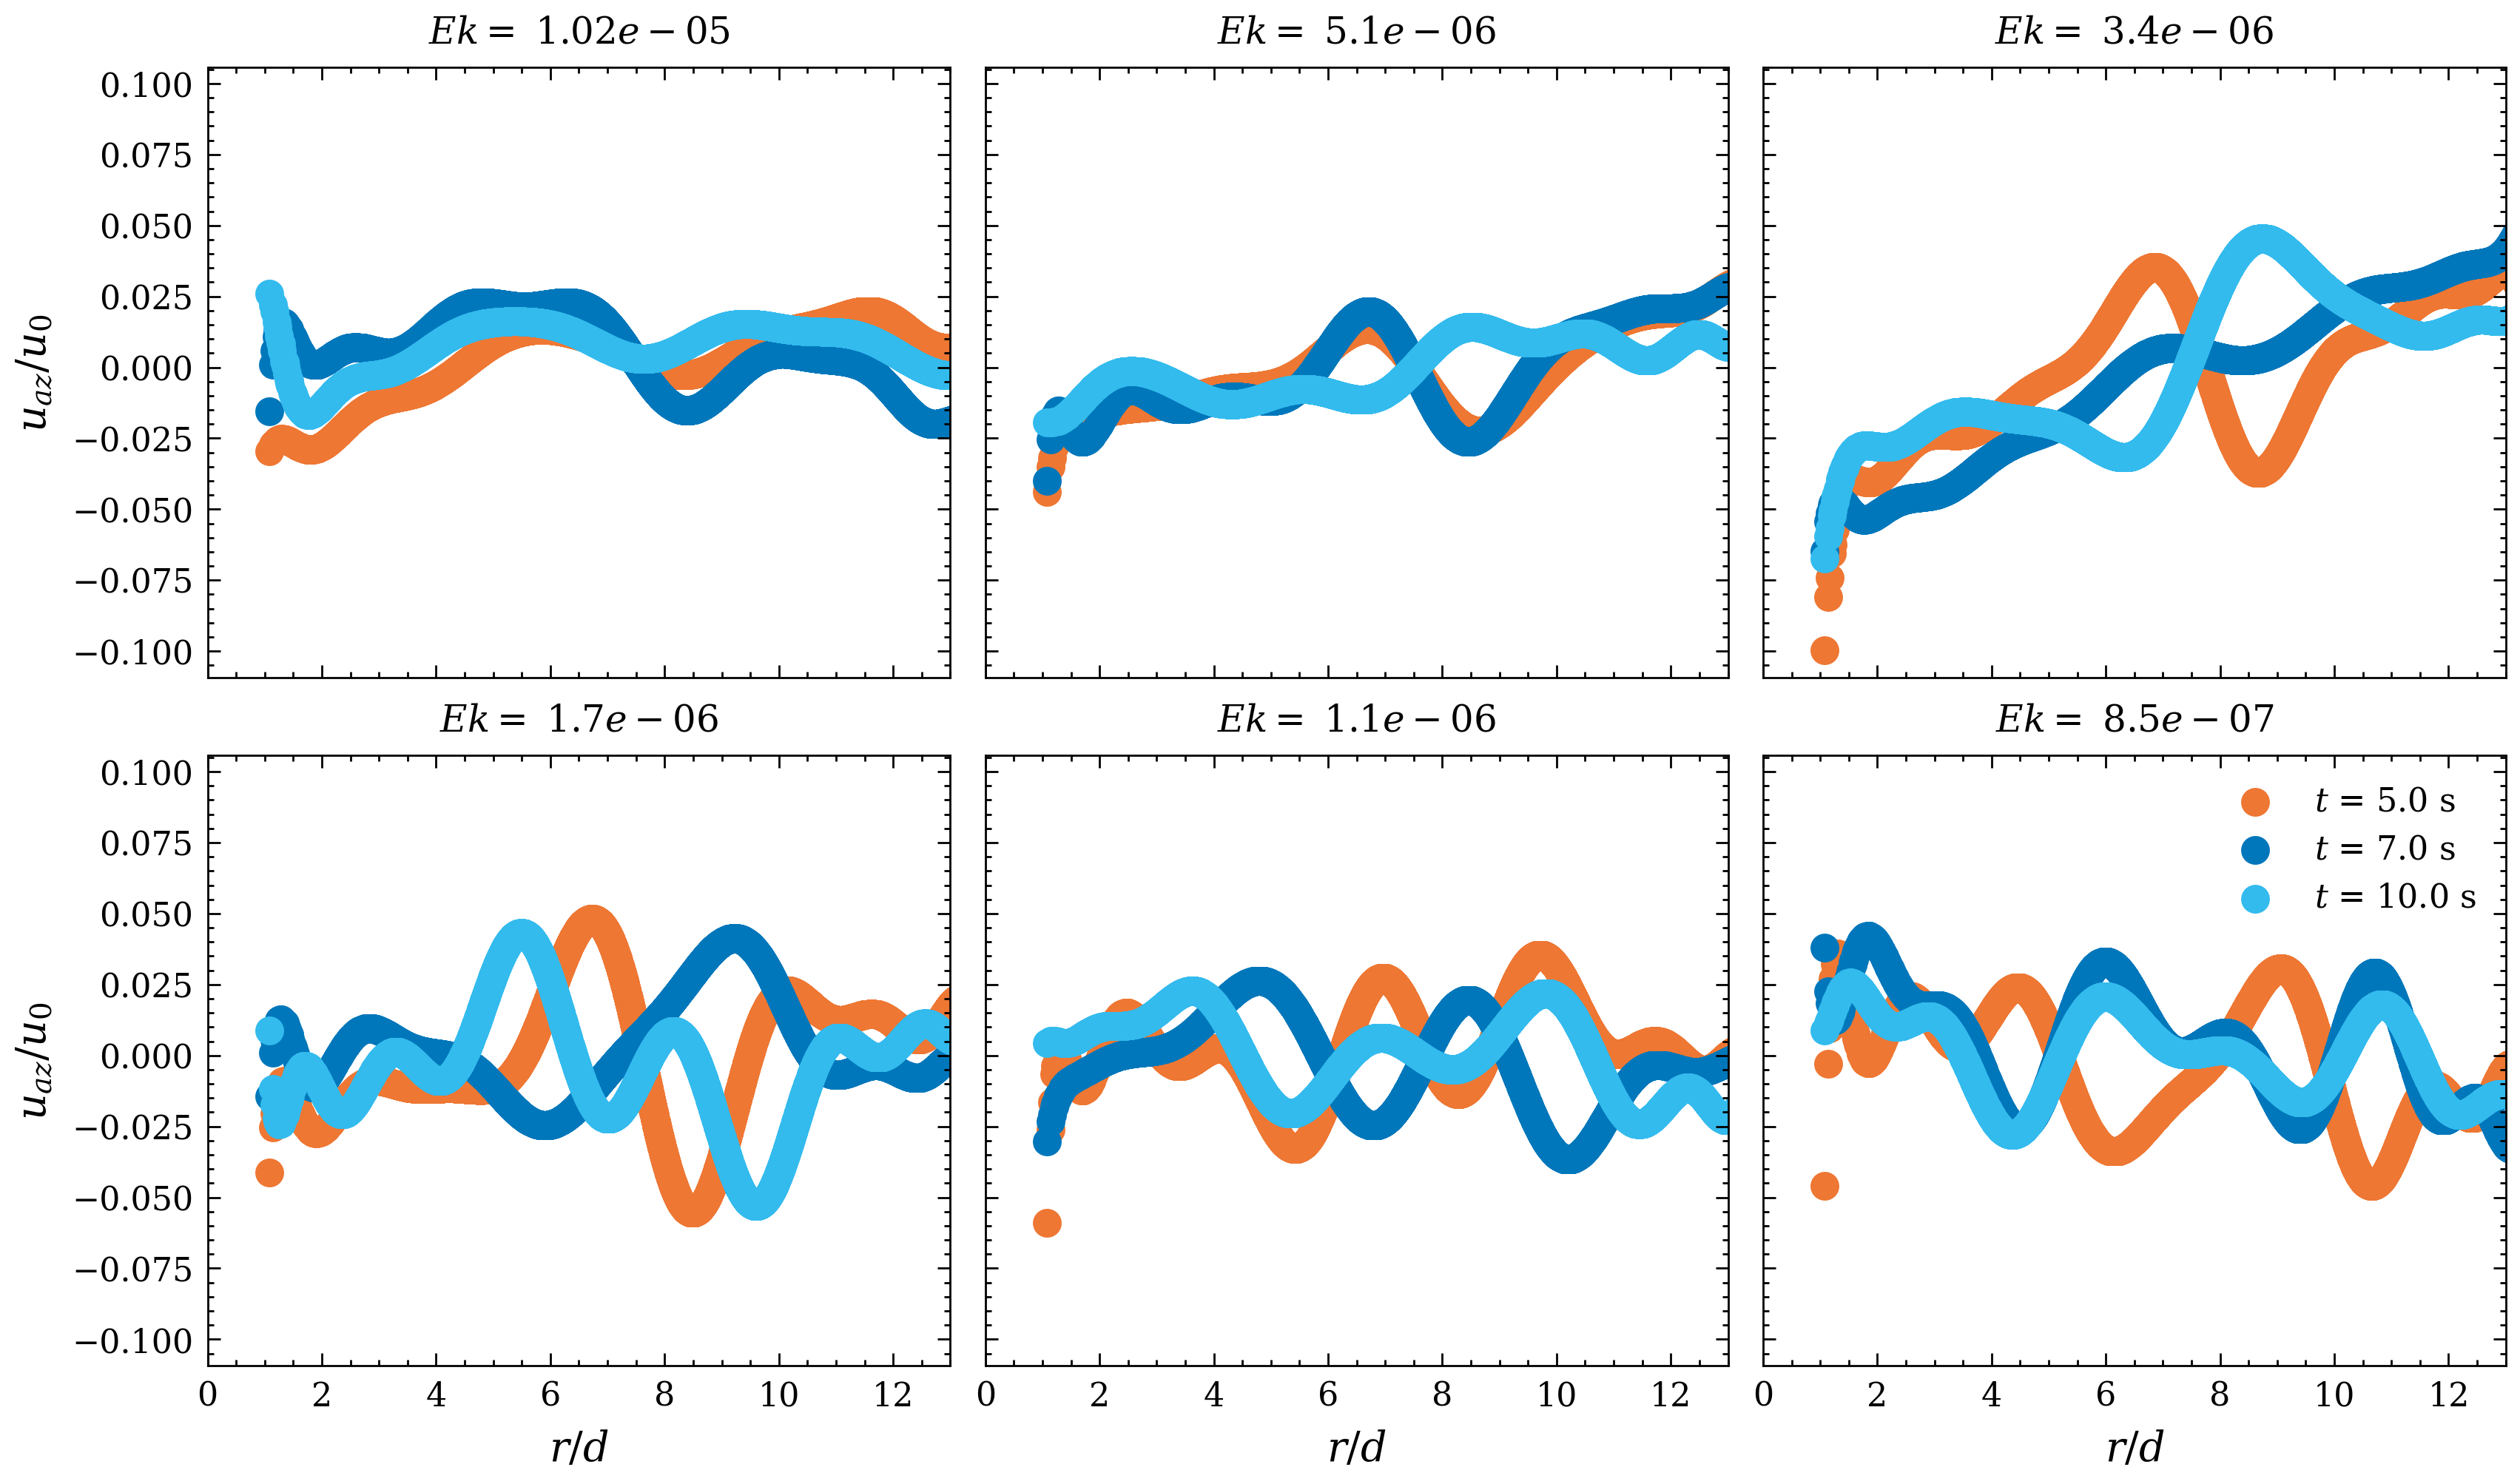

In [5]:
index = 0
rpms = [1, 2, 3, 6, 9, 12]

Eks = [0.0000102, 0.0000051, 0.0000034, 0.0000017, 0.0000011, 0.00000085]

fig, axs = plt.subplots(2, 3,sharex=True, sharey=True, figsize=(8.5, 5))
for i in range(2):
    for j in range(3):

        vels = h5file['3D0']['U100']['L100'][f'RPM{str(rpms[index])}']
        u = vels[:,:,:,0]
        v = vels[:,:,:,1]
        # u, v = oj.scaleVelNozzle(u, v, 150) #make suer to change this for the wide fov data


        for frame in range(len(frames)):
            # colorGen = cmap1(int(frame) / 540)
            ax = axs[i, j]
            r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[frames[frame],:,:], v[frames[frame],:,:])
            r_arr, theta_arr, U_rBins, U_azBins = oj.binCylindrical(r, theta, U_r, U_az, thetaBins=30, rBins=100)
            inds = (r.flatten()).argsort()
            r2 = (r.flatten())[inds]
            U_r2 = (U_r.flatten())[inds]
            pr = np.poly1d(np.polyfit(r2, U_r2, 21))(r2) #This turns the graph into a polynomial line
            U_az2 = (U_az.flatten())[inds]
            paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
            ax.scatter(r2*0.1, paz, label=fr'$t$ = {times[frame]} s')
            ax.set_xlim(0, 13)
            # ax.set_ylim(-0.4, 0.3)
            ax.set_title(f"$Ek = ~{Eks[index]}$", size=9)
        index += 1

axs[0, 0].set_ylabel(r'$u_{az}/u_{0}$')
axs[1, 0].set_ylabel(r'$u_{az}/u_{0}$')
axs[1, 0].set_xlabel(r'$r/d$')
axs[1, 1].set_xlabel(r'$r/d$')
axs[1, 2].set_xlabel(r'$r/d$')
axs[1, 2].legend(fontsize=8)
plt.legend(fontsize=8)
plt.show()

Mean and peak plots

C:\Users\u2088308\AppData\Local\Temp\ipykernel_12616\490967107.py:29: RankWarning: Polyfit may be poorly conditioned
  paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)


Text(0, 0.5, 'radial location')

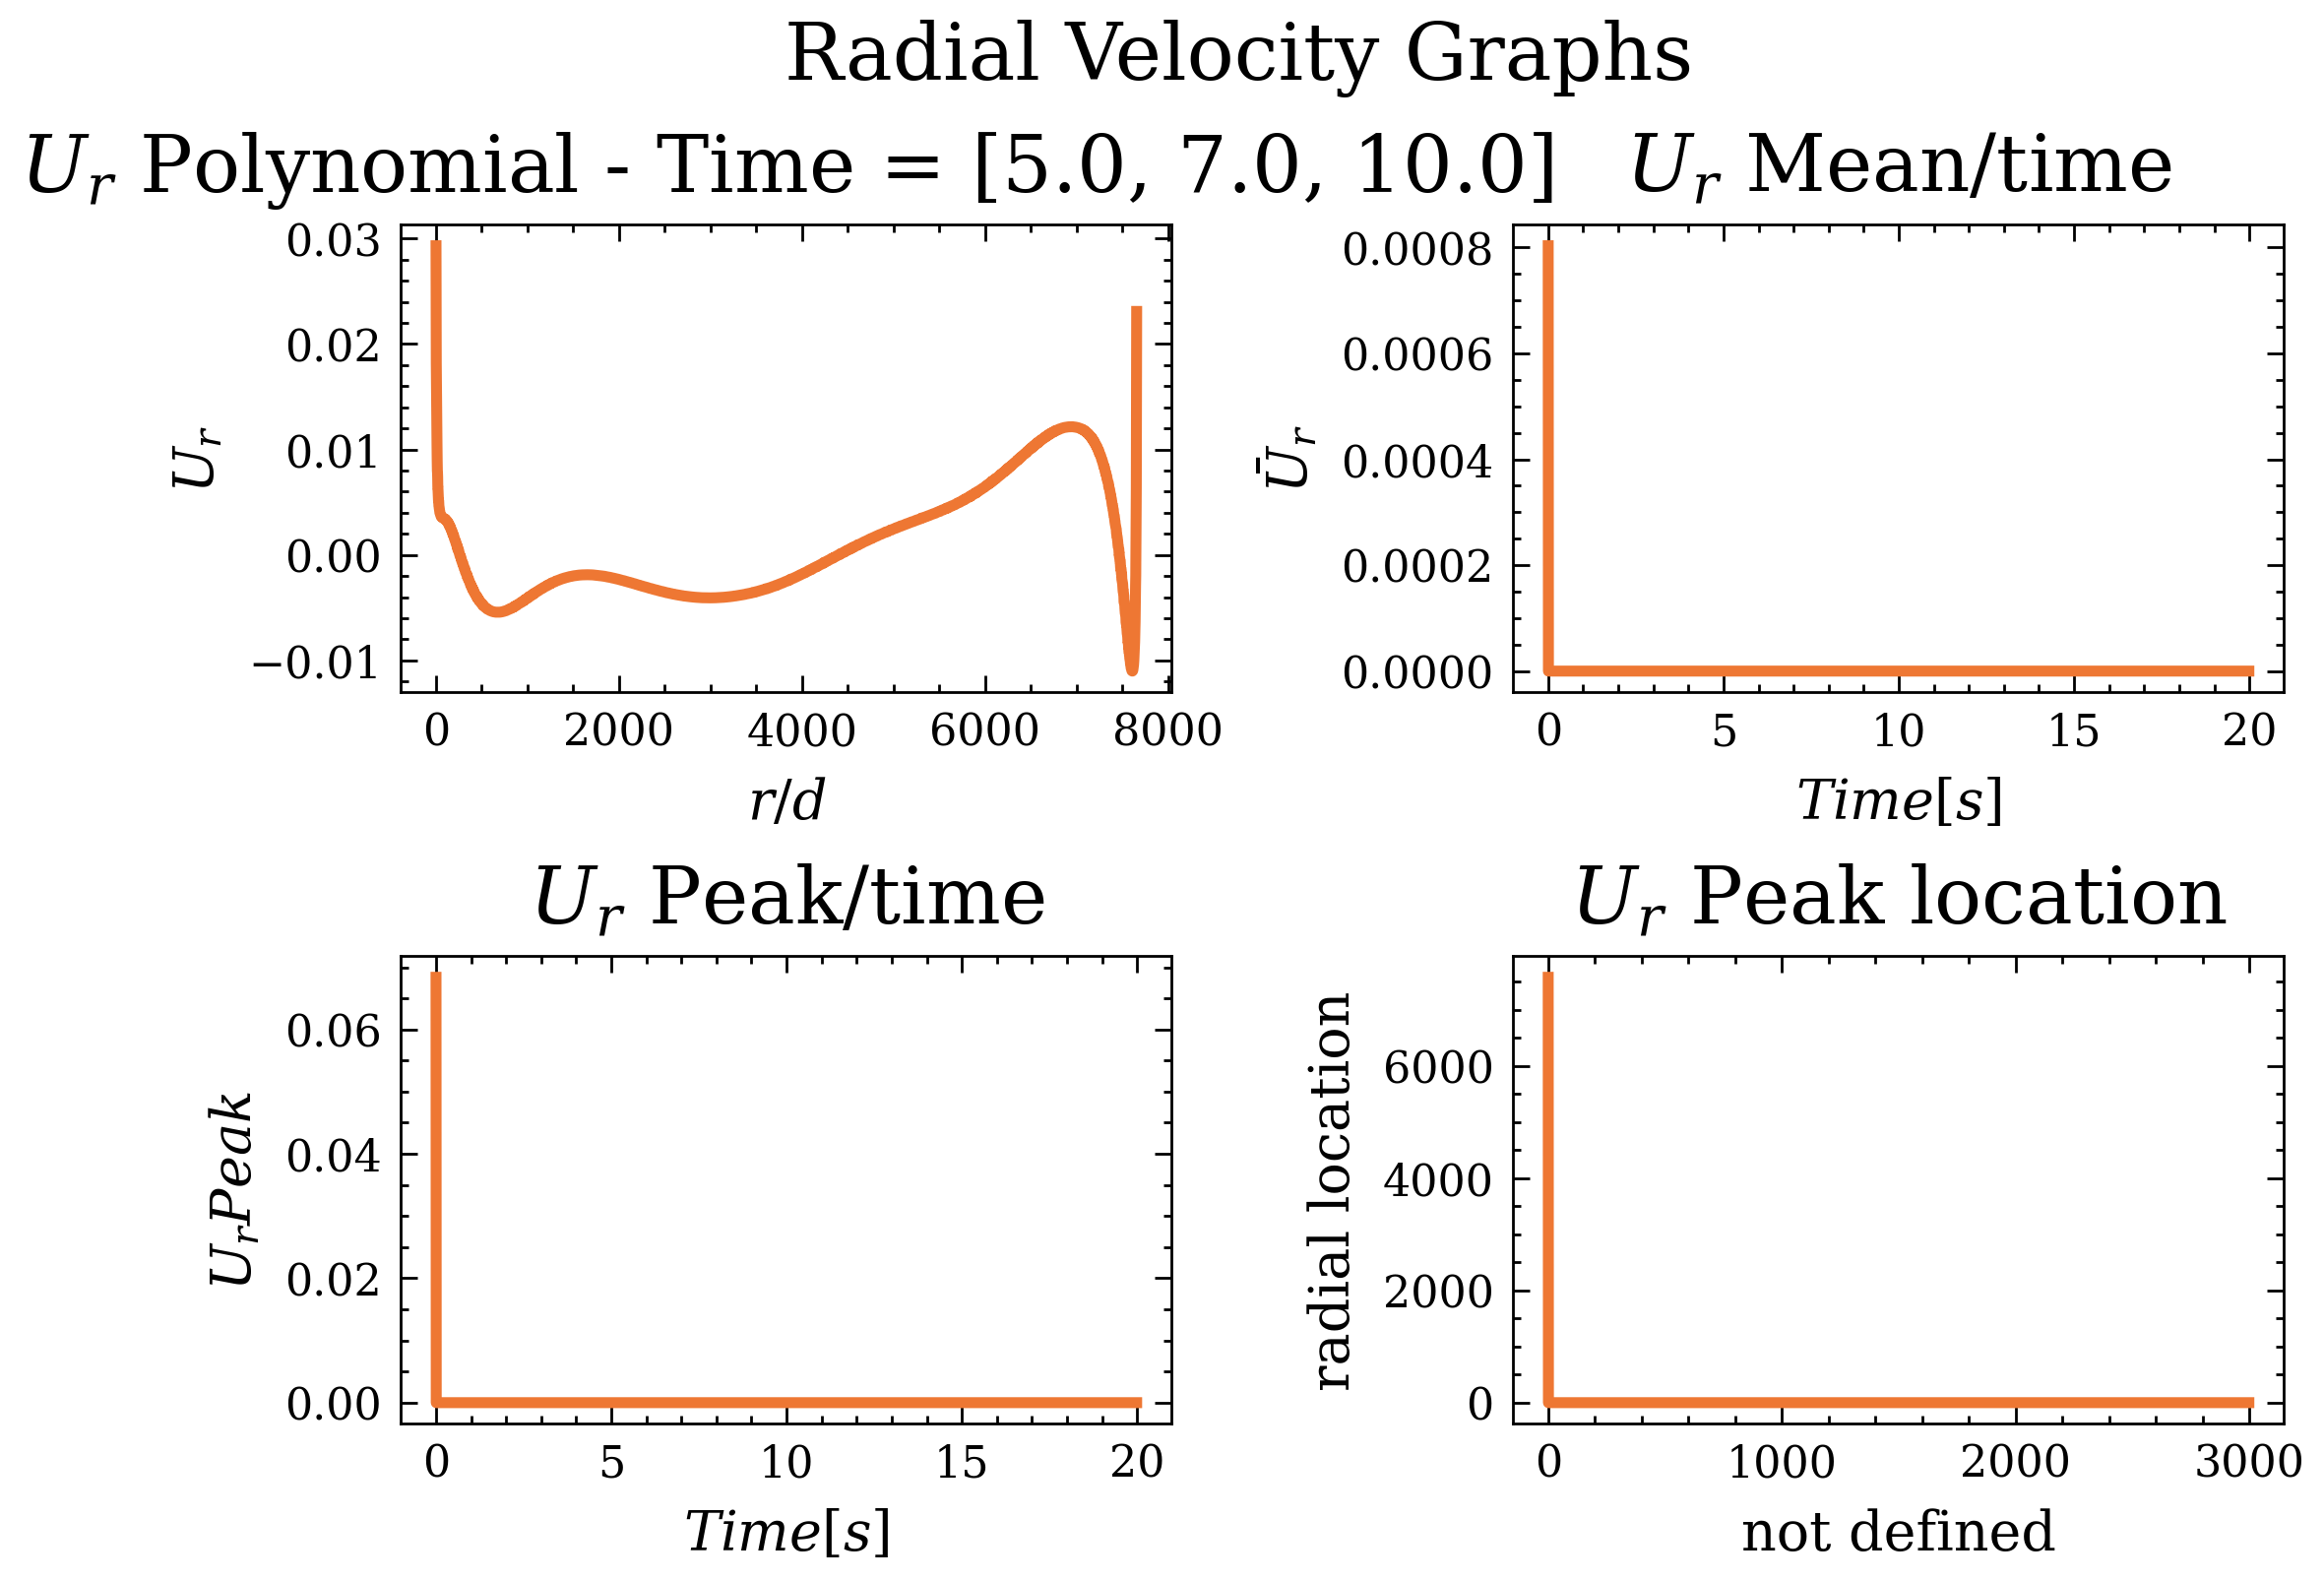

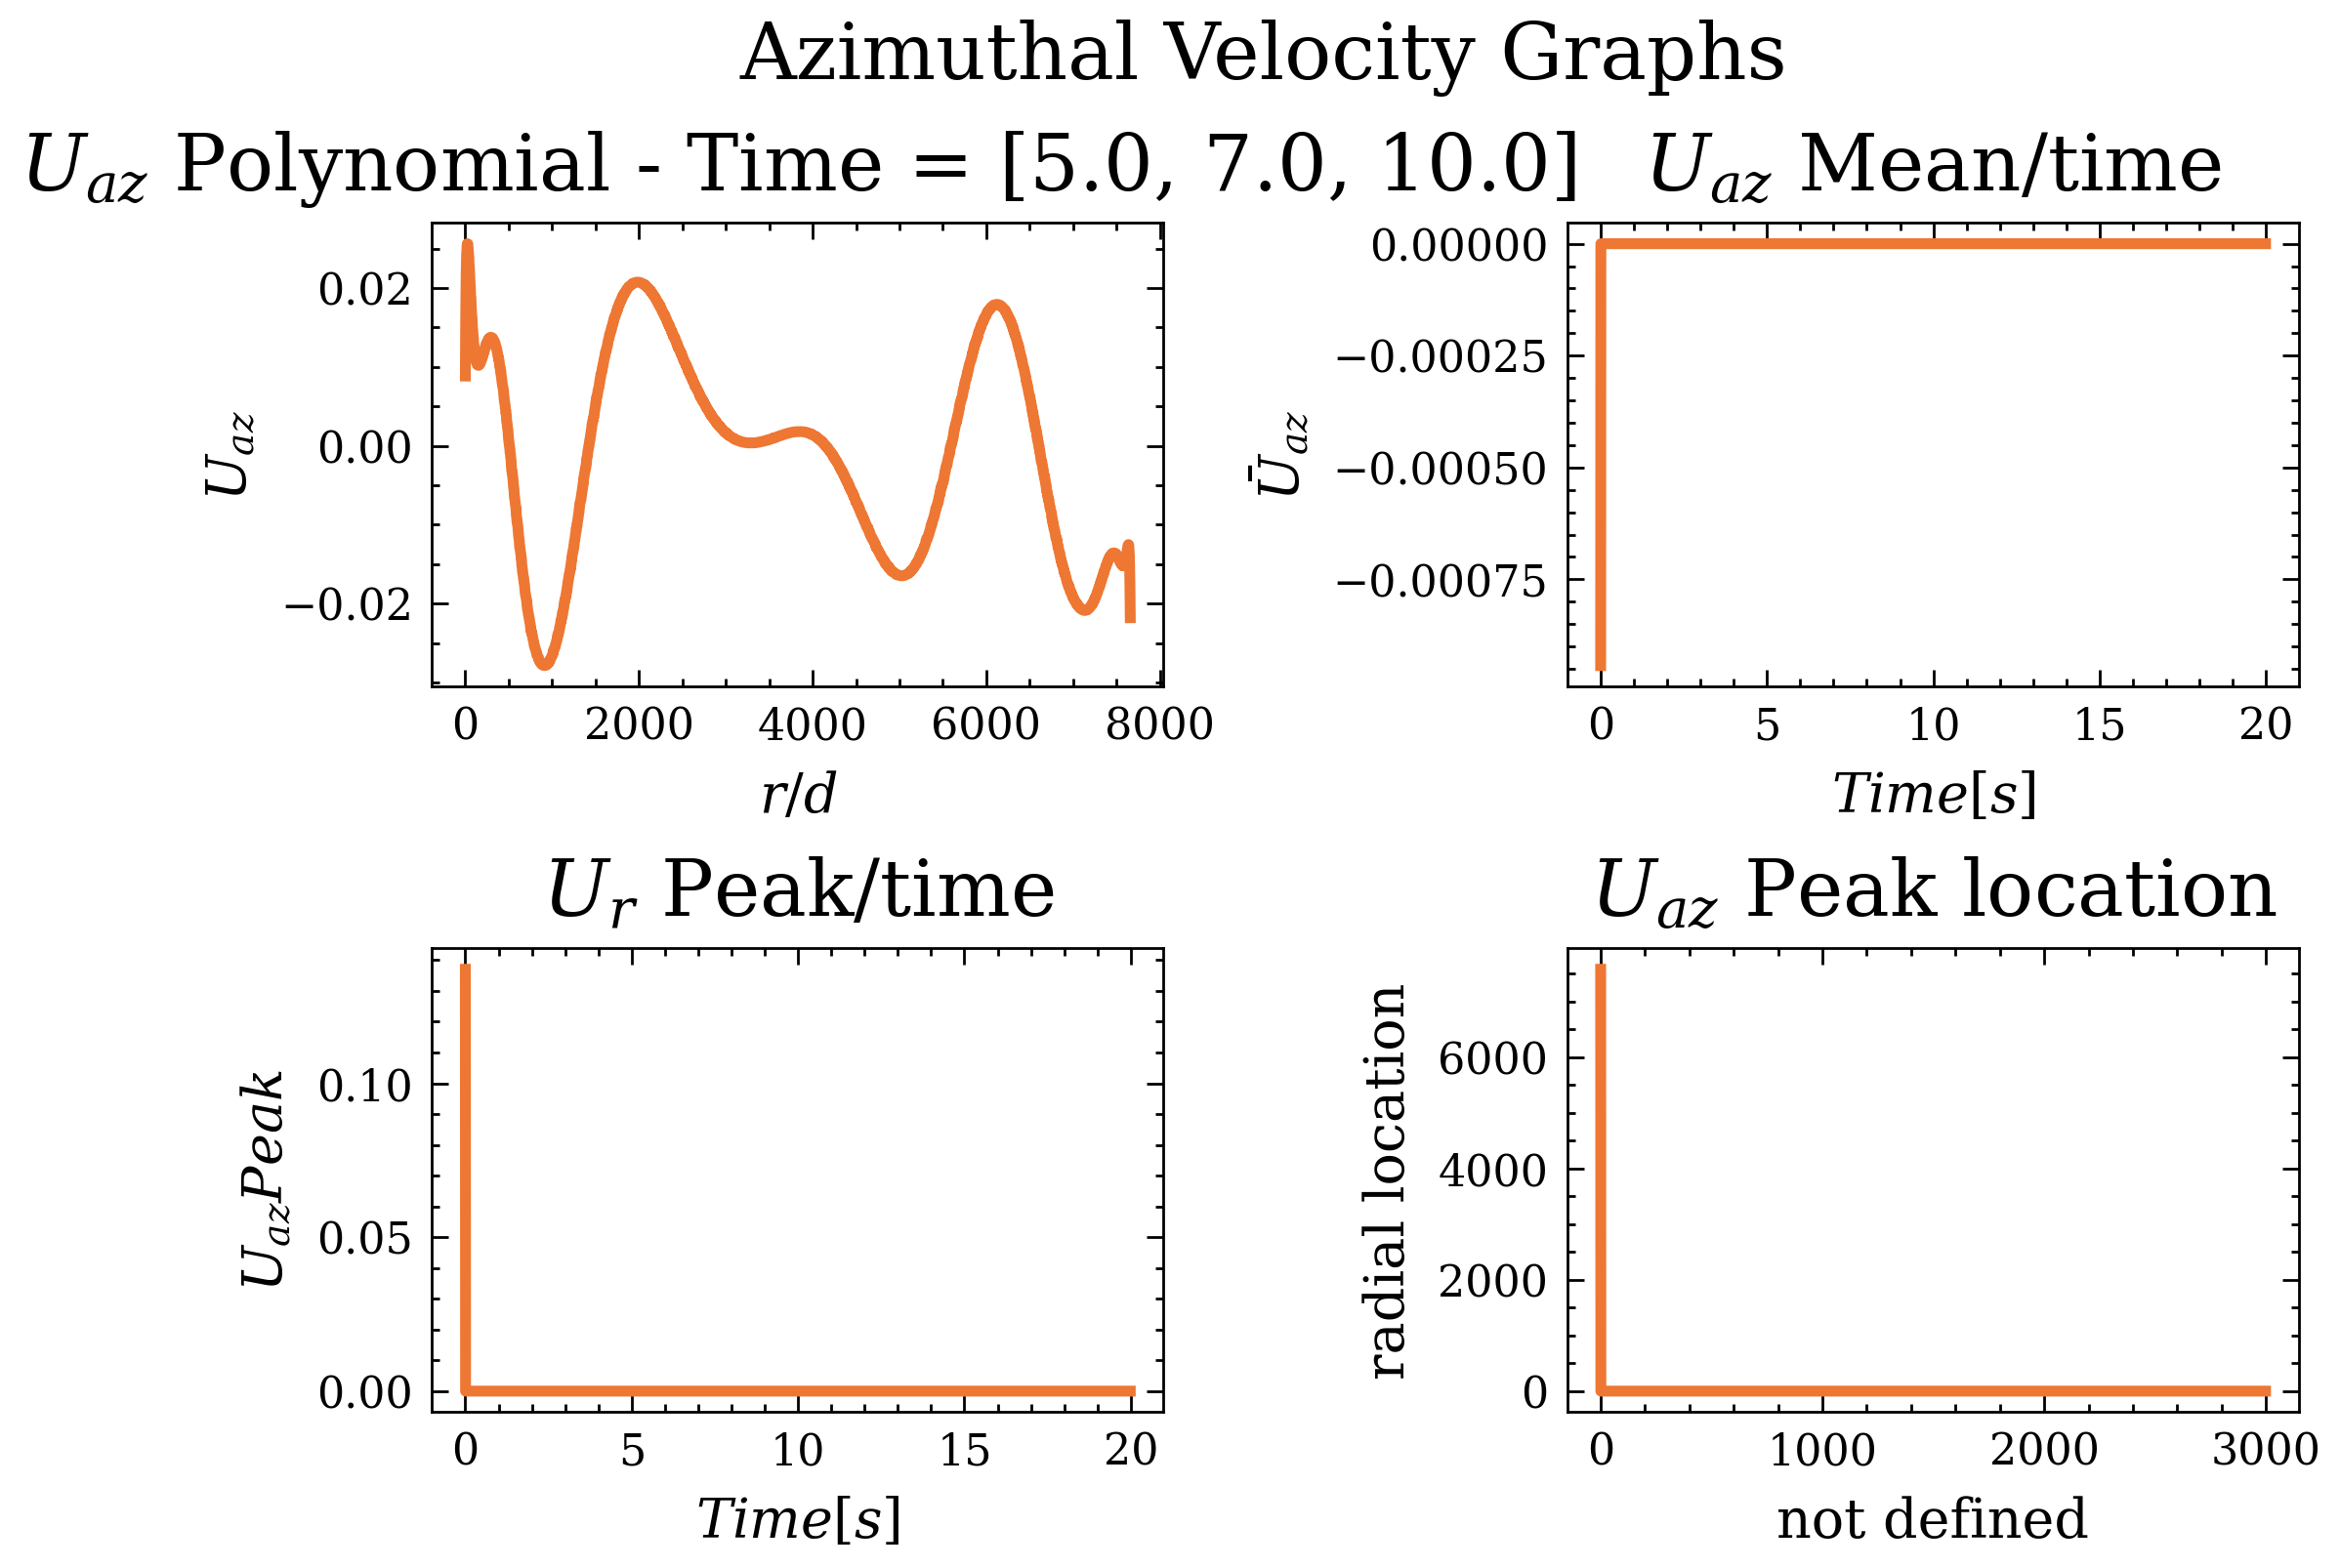

In [6]:
# h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
vels = h5file['3D0']['U100']['L100']['RPM0']
u = vels[:,:,:,0]
v = vels[:,:,:,1]
r_nd, z_nd = oj.NDUnitsForPlotsHoriz(u.shape[1], u.shape[2])
time = oj.frames_to_seconds(u, v, 150)
frames0 = [750, 1020, 1470]

radial_Position = np.zeros(u.shape[0])
U_r_Mean = np.zeros(u.shape[0])
U_r_Peak = np.zeros(u.shape[0])
U_az_Mean = np.zeros(u.shape[0])
U_az_Peak = np.zeros(u.shape[0])

x = np.linspace(0 , u.shape[2], u.shape[2])
y = np.linspace(0 , u.shape[1], u.shape[1])
xc = int(u.shape[2]/2)
yc = int(u.shape[1]/2)

# for i in range(u.shape[0]):
for i in range(1):
# for i in range(10): # for testing
    r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(120, 75, x, y, u[i,:,:], v[i,:,:])
    inds = (r.flatten()).argsort()
    r2 = (r.flatten())[inds]
    U_r2 = (U_r.flatten())[inds]
    pr = np.poly1d(np.polyfit(r2, U_r2, 11))(r2) #This turns the graph into a polynomial line
    paz = np.poly1d(np.polyfit(r2, U_az2, 21))(r2)
    # max = np.argmax(U_az2)
    max = np.argmax(p)
    U_r_Mean[i] = np.mean(U_r2)
    U_r_Peak[i] = np.max(U_r2)
    U_az_Mean[i] = np.mean(U_az2)
    U_az_Peak[i] = np.max(U_az2)
    radial_Position[i] = max


f5, ax = plt.subplots(2, 2)
plt.suptitle("Radial Velocity Graphs")
# ax[0,0].plot(U_r2)
ax[0,0].plot(pr)
ax[0,0].set_title(r"$U_{r}$ Polynomial" + f" - Time = {times}")
ax[0,0].set_xlabel("$r/d$")
ax[0,0].set_ylabel(r"$U_{r}$")
ax[0,1].plot(time, U_r_Mean)
ax[0,1].set_title(r"$U_{r}$ Mean/time")
ax[0,1].set_xlabel("$Time [s]$")
ax[0,1].set_ylabel(r"$\bar{U}_{r}$")
ax[1,0].plot(time, U_r_Peak)
ax[1,0].set_title(r"$U_{r}$ Peak/time")
ax[1,0].set_xlabel("$Time [s]$")
ax[1,0].set_ylabel(r"$U_{r} Peak$")
ax[1,1].plot(radial_Position)
ax[1,1].set_title(r"$U_{r}$ Peak location")
ax[1,1].set_xlabel("not defined")
ax[1,1].set_ylabel("radial location")


f6, ax = plt.subplots(2, 2)
plt.suptitle("Azimuthal Velocity Graphs")
# ax[0,0].plot(U_r2)
ax[0,0].plot(paz)
ax[0,0].set_title(r"$U_{az}$ Polynomial" + f" - Time = {times}")
ax[0,0].set_xlabel("$r/d$")
ax[0,0].set_ylabel(r"$U_{az}$")
ax[0,1].plot(time, U_az_Mean)
ax[0,1].set_title(r"$U_{az}$ Mean/time")
ax[0,1].set_xlabel("$Time [s]$")
ax[0,1].set_ylabel(r"$\bar{U}_{az}$")
ax[1,0].plot(time, U_az_Peak)
ax[1,0].set_title(r"$U_{r}$ Peak/time")
ax[1,0].set_xlabel("$Time [s]$")
ax[1,0].set_ylabel(r"$U_{az} Peak$")
ax[1,1].plot(radial_Position)
ax[1,1].set_title(r"$U_{az}$ Peak location")
ax[1,1].set_xlabel("not defined")
ax[1,1].set_ylabel("radial location")

Multiple rotation rates:
peak and mean normalised by $\Omega$

In [7]:
frametime = frame/150
# rate = rpms[5]/60

xc = u.shape[2]/2
yc = u.shape[1]/2

# f5, ax = plt.subplots(2, 2)
# plt.suptitle("Radial Velocity Graphs")
# ax[0,0].plot(pr)
# ax[0,0].set_title(r"$U_{r}$ Polynomial" + f" - Time = {frametime}")
# ax[0,0].set_xlabel("$r/d$")
# ax[0,0].set_ylabel(r"$U_{r}$")
# ax[0,1].plot(time*rate, U_r_Mean)
# ax[0,1].set_title(r"$U_{r}$ Mean/time")
# ax[0,1].set_xlabel("$Time [s]$")
# ax[0,1].set_ylabel(r"$\bar{U}_{r}$")
# ax[1,0].plot(time, U_r_Peak)
# ax[1,0].set_title(r"$U_{r}$ Peak/time")
# ax[1,0].set_xlabel("$Time [s]$")
# ax[1,0].set_ylabel(r"$U_{r} Peak$")
# ax[1,1].plot(time, radial_Position)
# ax[1,1].set_title(r"$U_{r}$ Peak location")
# ax[1,1].set_xlabel("not defined")
# ax[1,1].set_ylabel("radial location")

# f6, ax7 = plt.subplots()
# plt.suptitle(r"$U_{r}$ Peak/time")
# ax7.plot(time, U_r_Peak,  color = 'b')
# ax7.set_xlabel("$Time [s]$")
# ax7.set_ylabel(r"$U_{r} Peak$")
# plt.show()

radial_Positionr = np.zeros([7, u.shape[0]])
U_r_Mean =         np.zeros([7, u.shape[0]])
U_r_Peak =         np.zeros([7, u.shape[0]])

radial_Positionaz = np.zeros([7, u.shape[0]])
U_az_Mean =         np.zeros([7, u.shape[0]])
U_az_Peak =         np.zeros([7, u.shape[0]])


######
# multiple rings
######
# h5file = h5py.File('E:/H5/3D0HLSFine.h5', 'r')
h5file = h5py.File('E:/H5/3D0meandataHLS.h5', 'r')
rpms = [1, 2, 3, 6, 9, 12]
for i in range(len(rpms)):
# for i in range(2):
    print('RPM{0}'.format(rpms[i]))
    vels = h5file['3D0']['U100']['L100']['RPM{0}'.format(rpms[i])]
    u = vels[:,:,:,0]
    v = vels[:,:,:,1]
    u_gaussian, v_gaussian = gaussian_filter(u, sigma=6), gaussian_filter(v, sigma=6)
    print(i)


    for j in range(u.shape[0]):
        r, theta, U_r, U_az, x0, y0 = oj.ConvertCylindrical(xc, yc, x, y, u_gaussian[j,:,:], v_gaussian[j,:,:])
        inds = (r.flatten()).argsort()
        r2 = (r.flatten())[inds]
        U_r2 = (U_r.flatten())[inds]
        pr = np.poly1d(np.polyfit(r2, U_r2, 11))(r2) #This turns the graph into a polynomial line
        U_r_Mean[i, j] = np.mean(U_r2)
        U_r_Peak[i, j] = np.max(U_r2)
        radial_Positionr[i, j] = np.argmax(pr[200:6000])

        U_az2 = (U_az.flatten())[inds]
        paz = np.poly1d(np.polyfit(r2, U_az2, 11))(r2) #This turns the graph into a polynomial line
        U_az_Mean[i, j] = np.mean(U_az2)
        U_az_Peak[i, j] = np.max(U_az2)
        radial_Positionaz[i, j] = np.argmax(paz[200:6000])


RPM1
0
RPM2
1
RPM3
2
RPM6
3
RPM9
4
RPM12
5


(-0.1, 13.0)

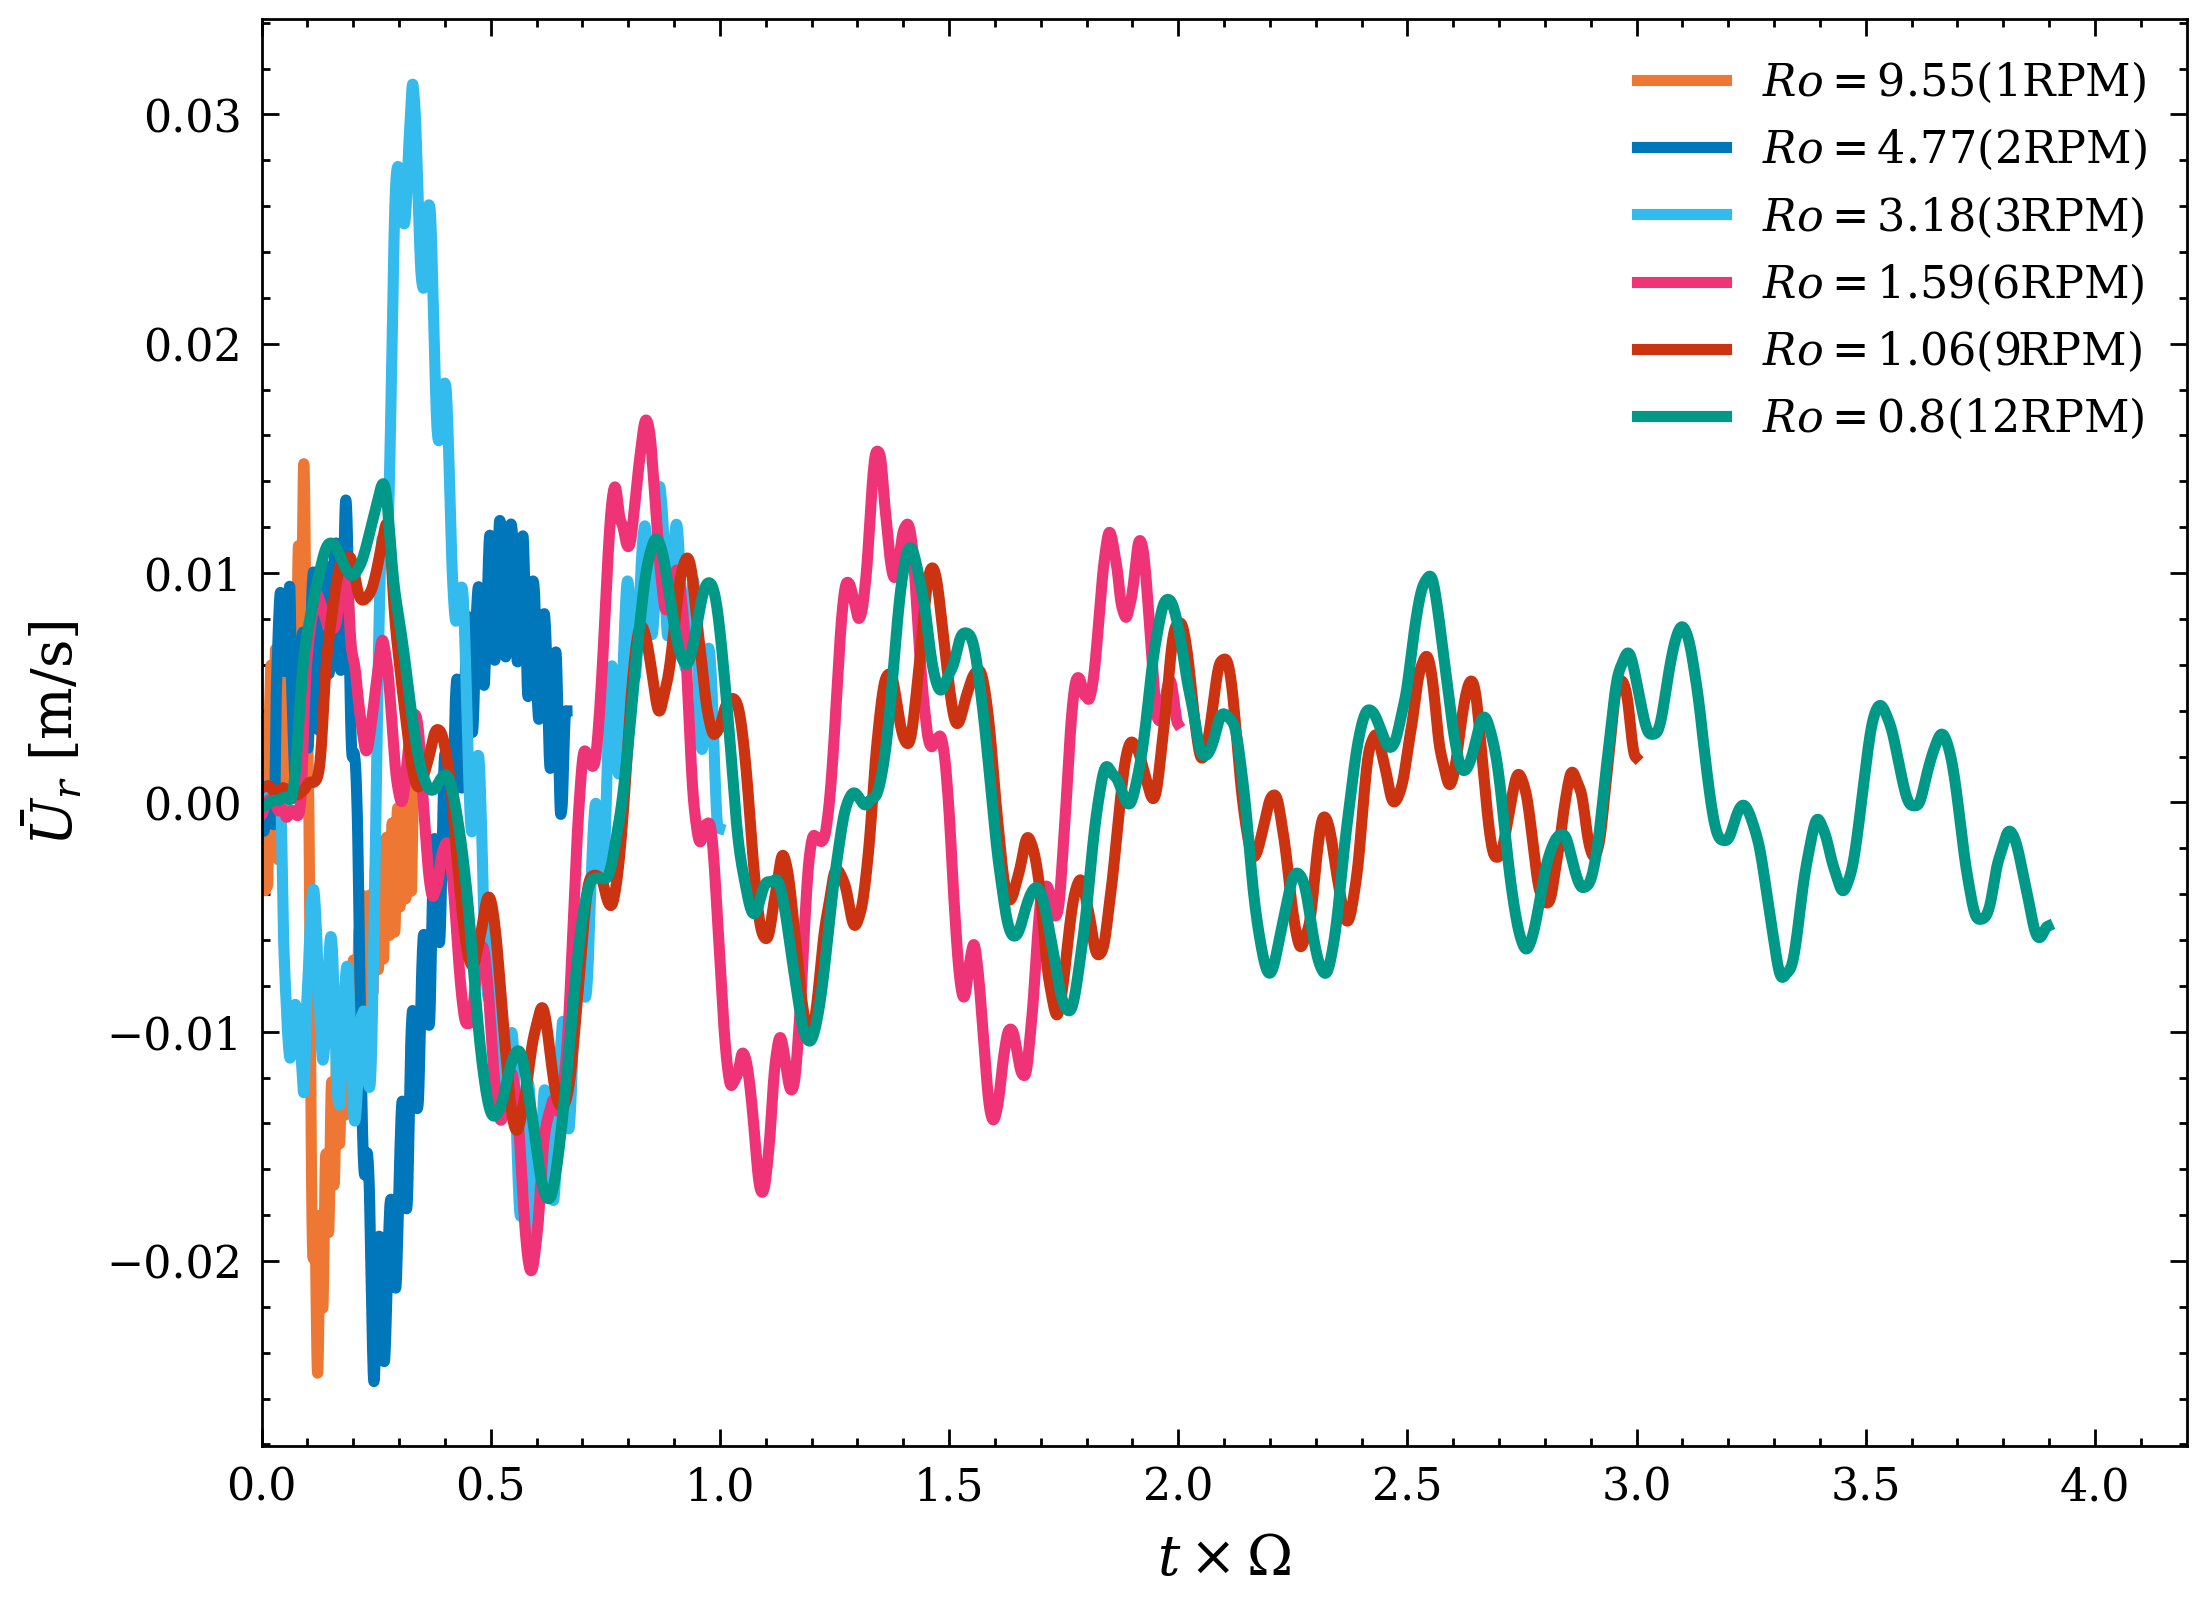

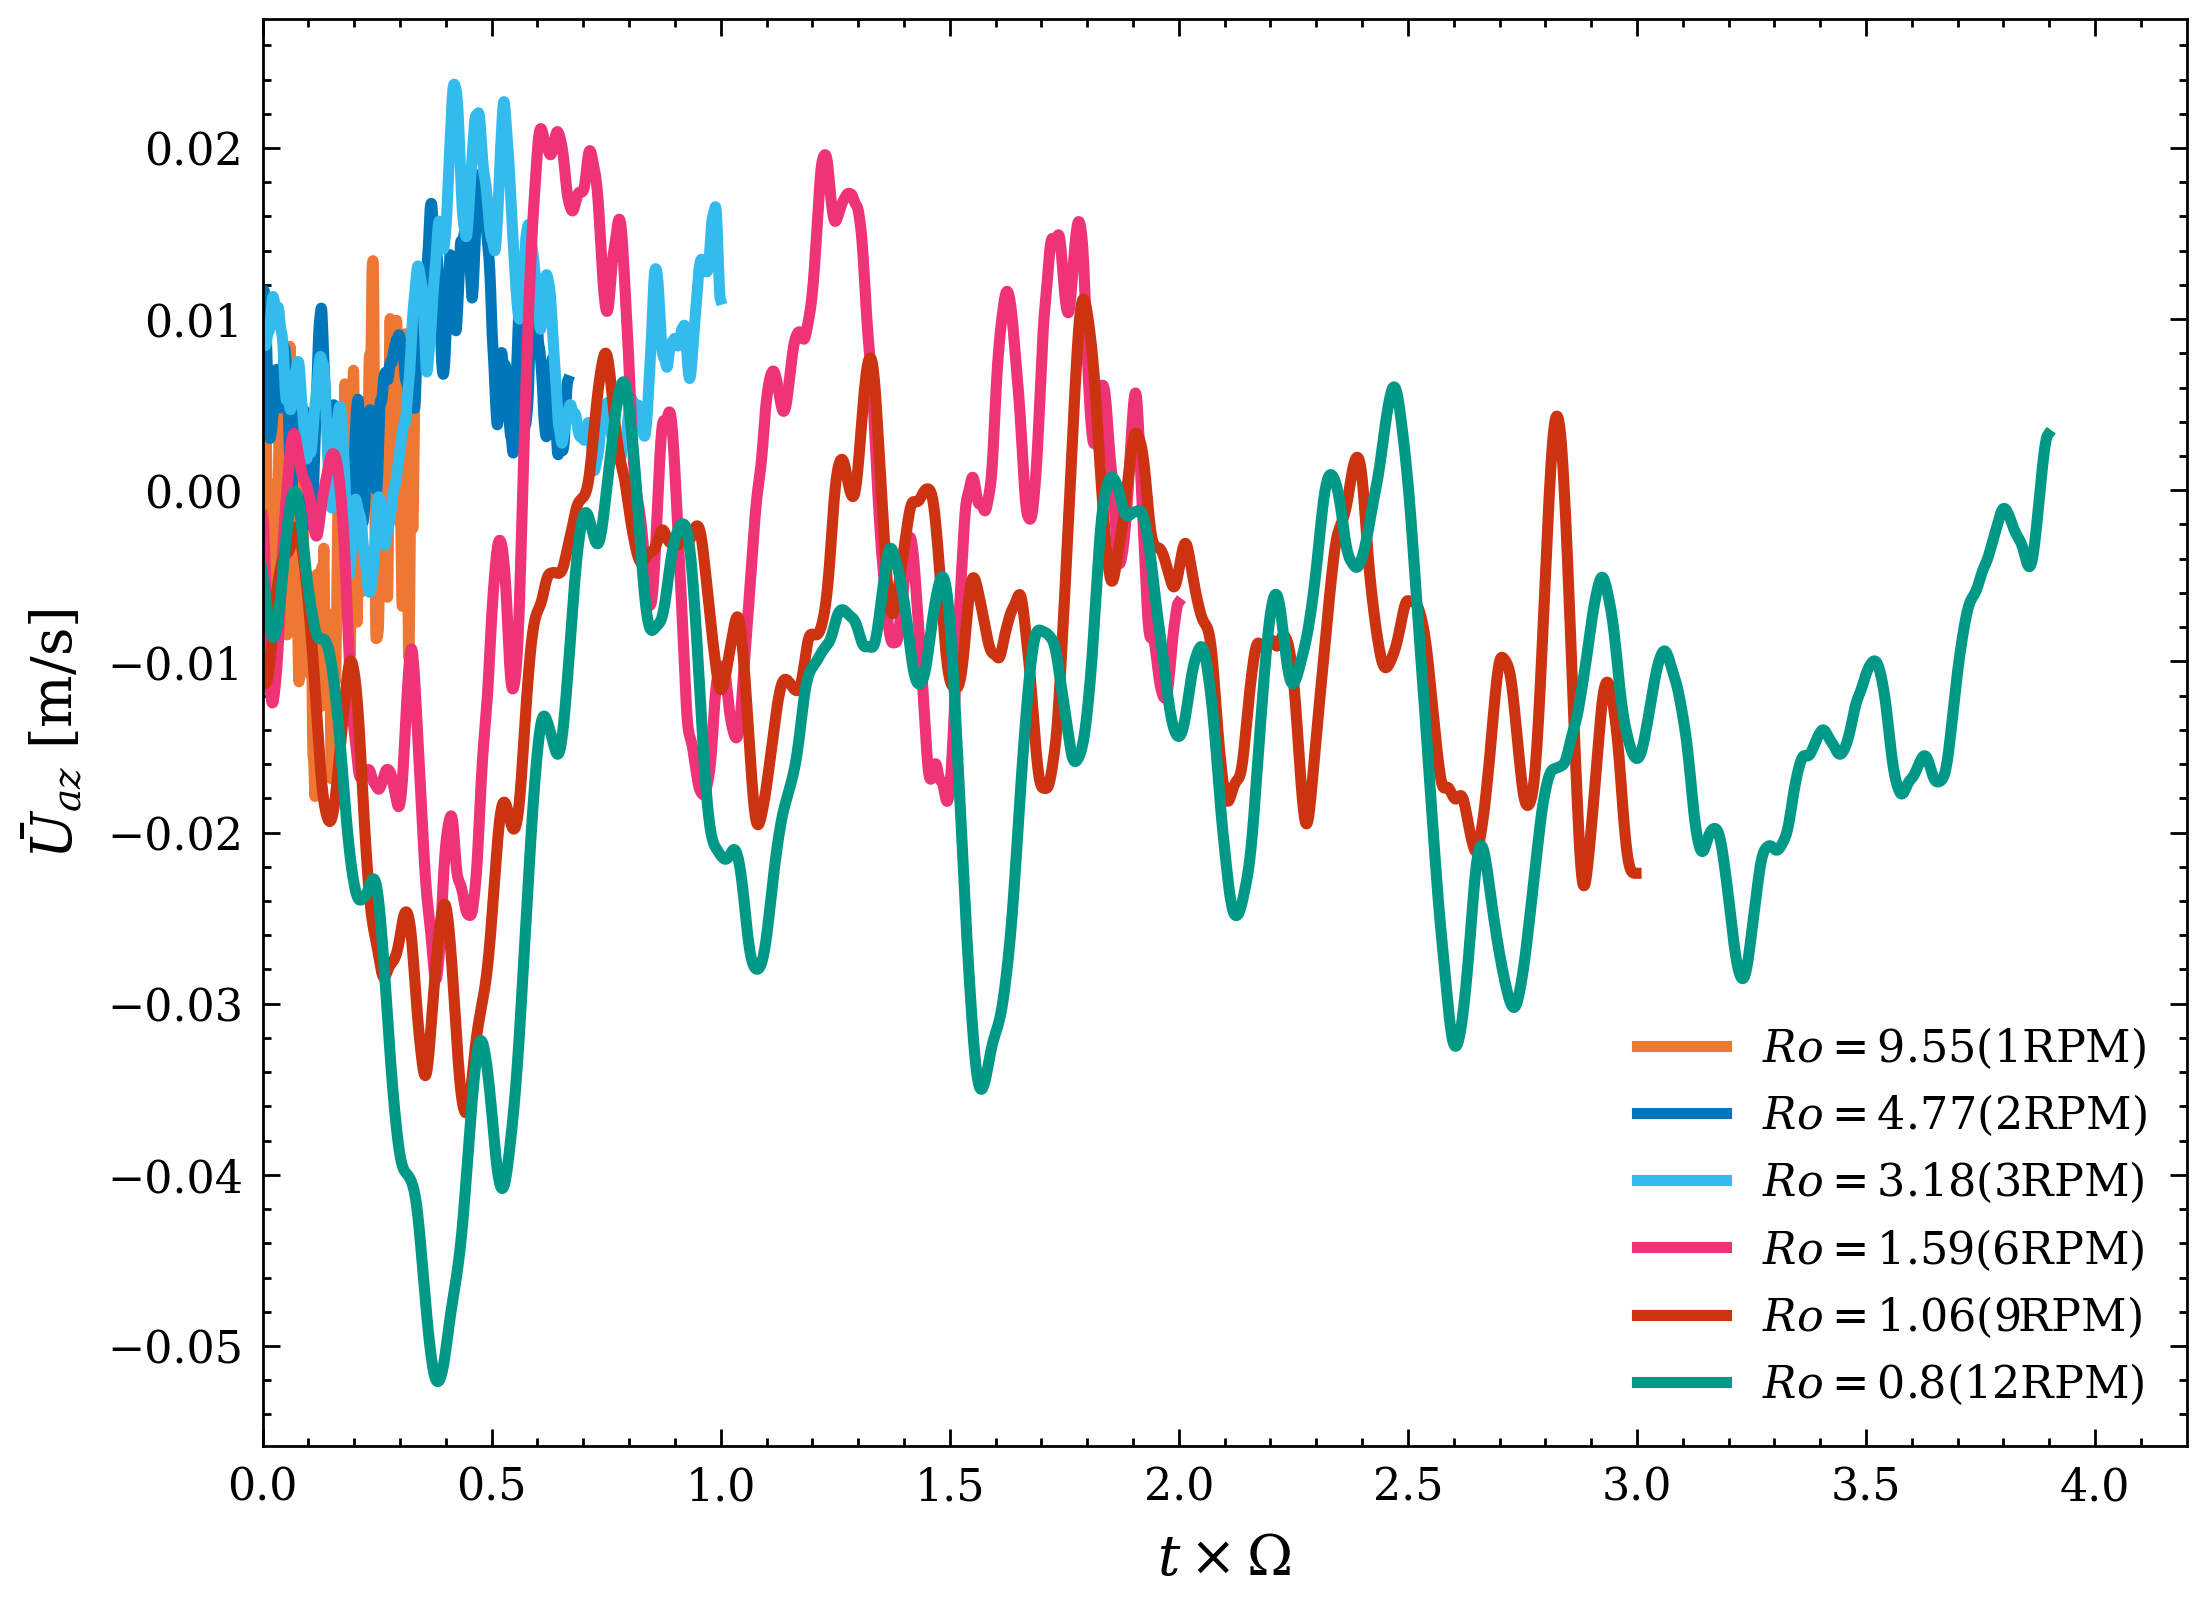

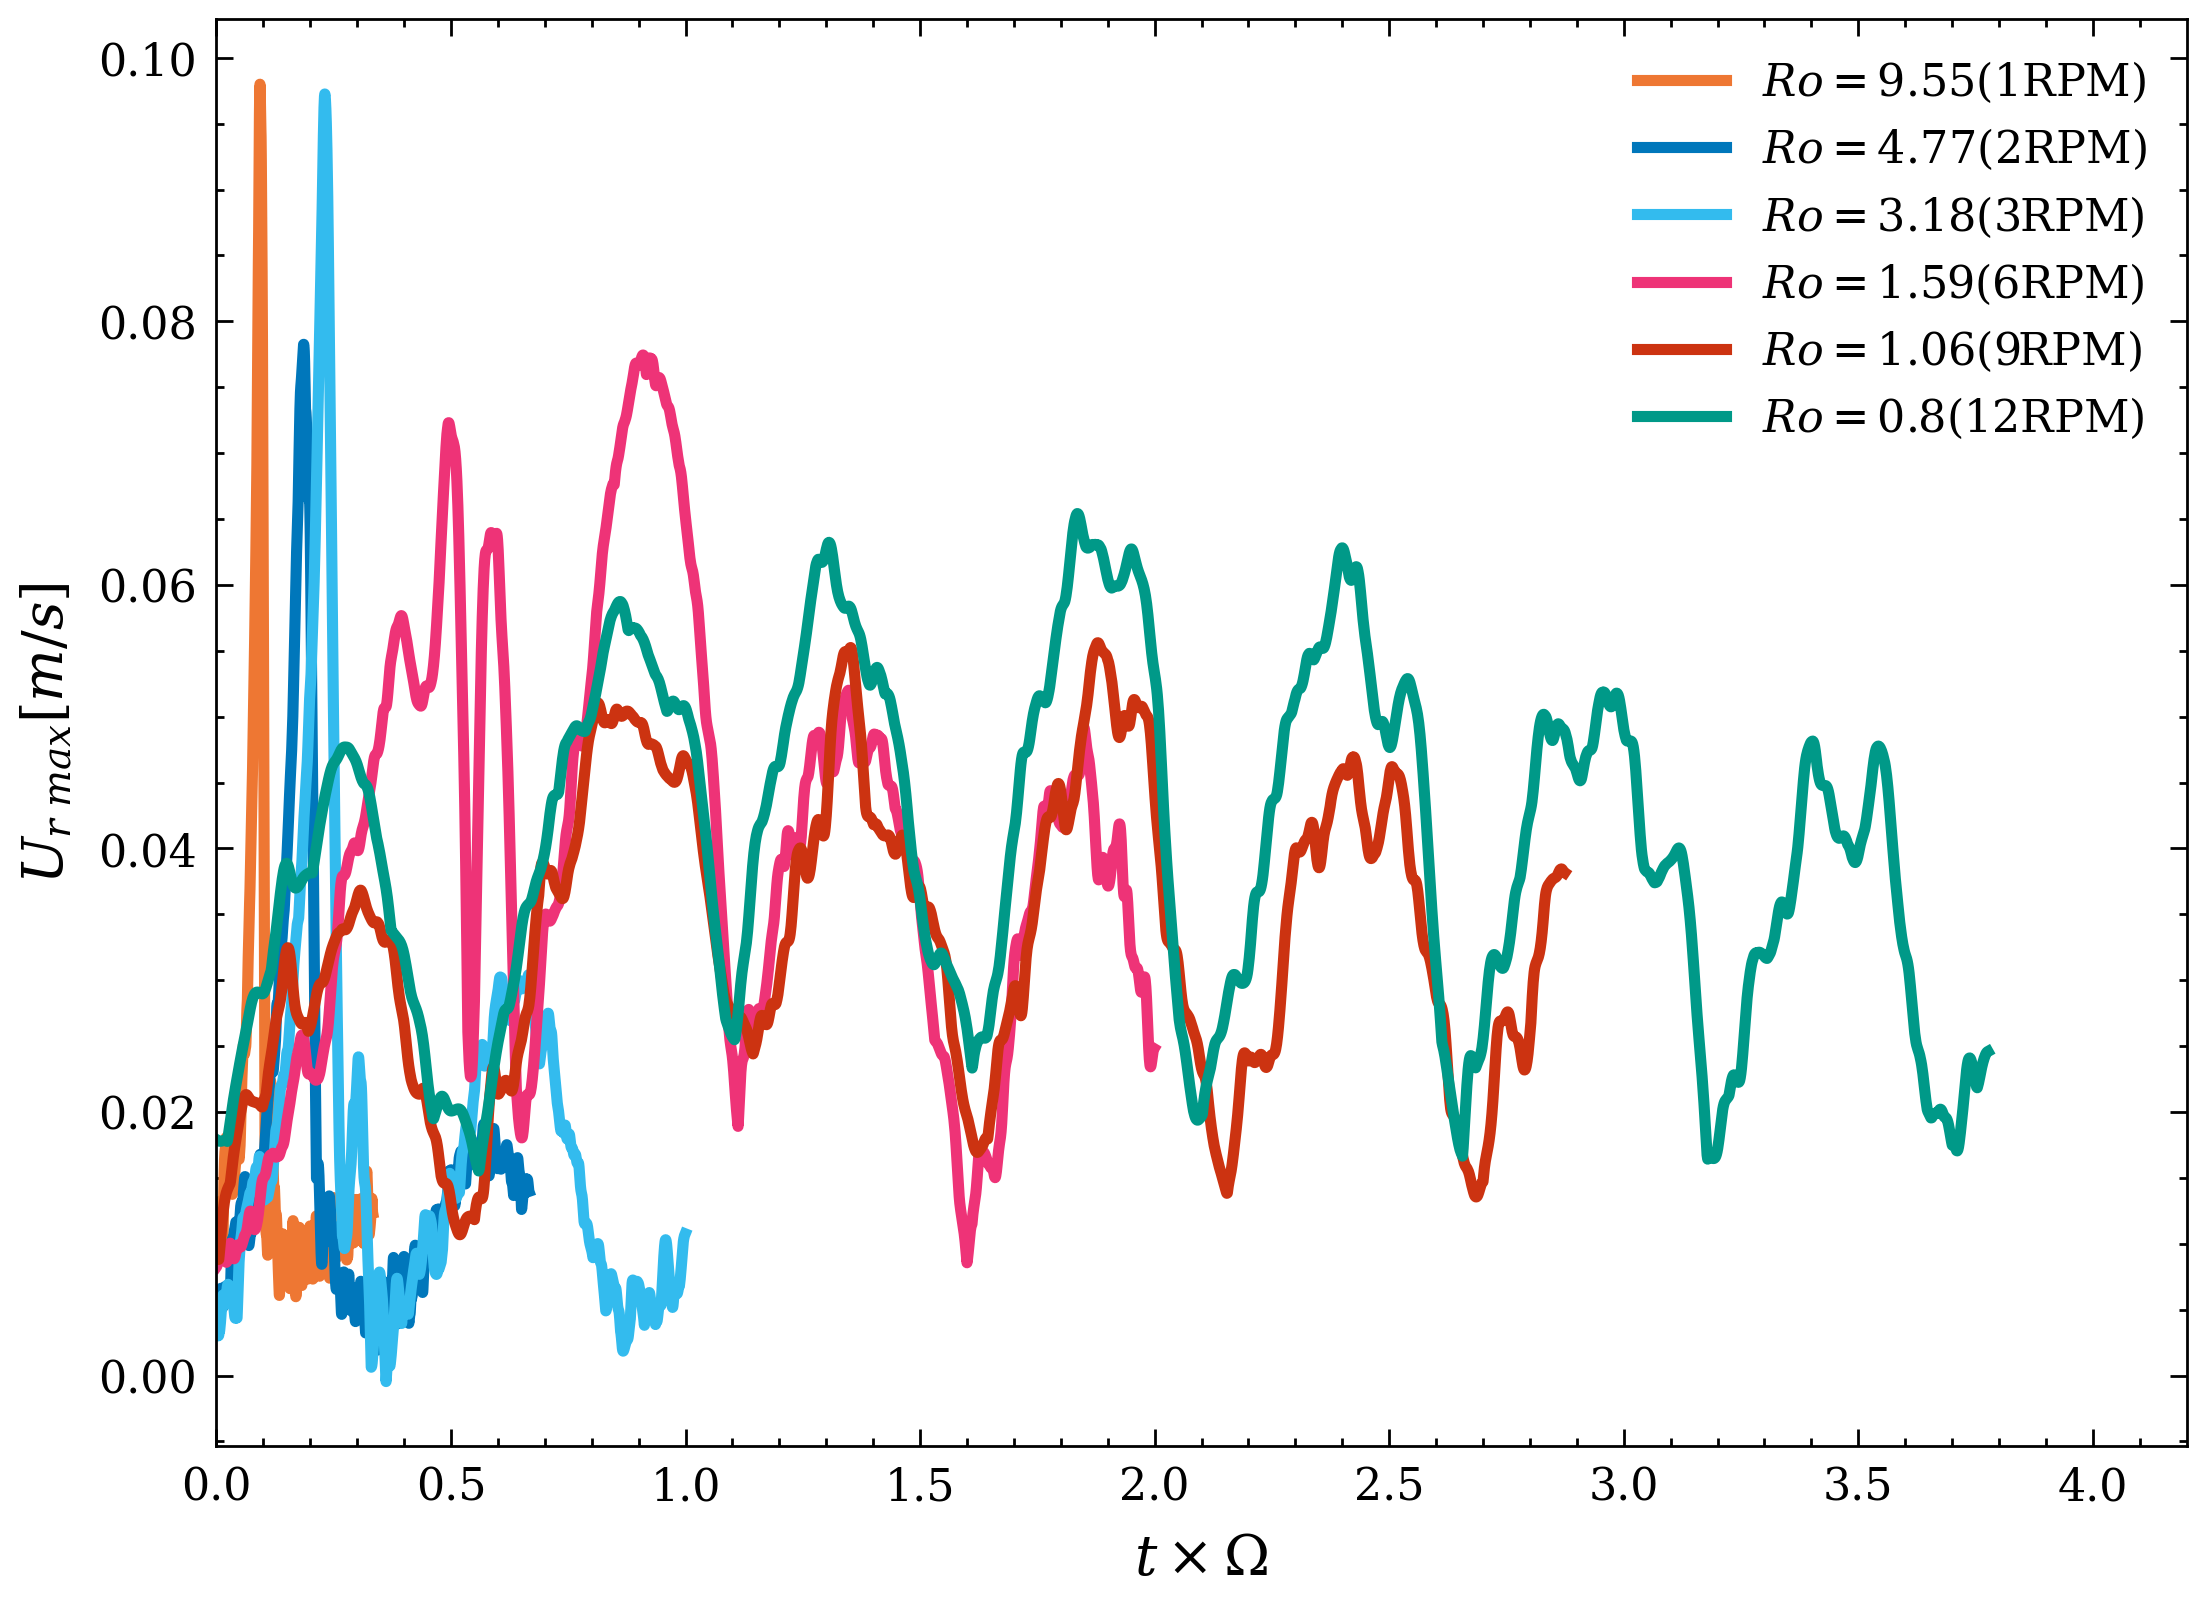

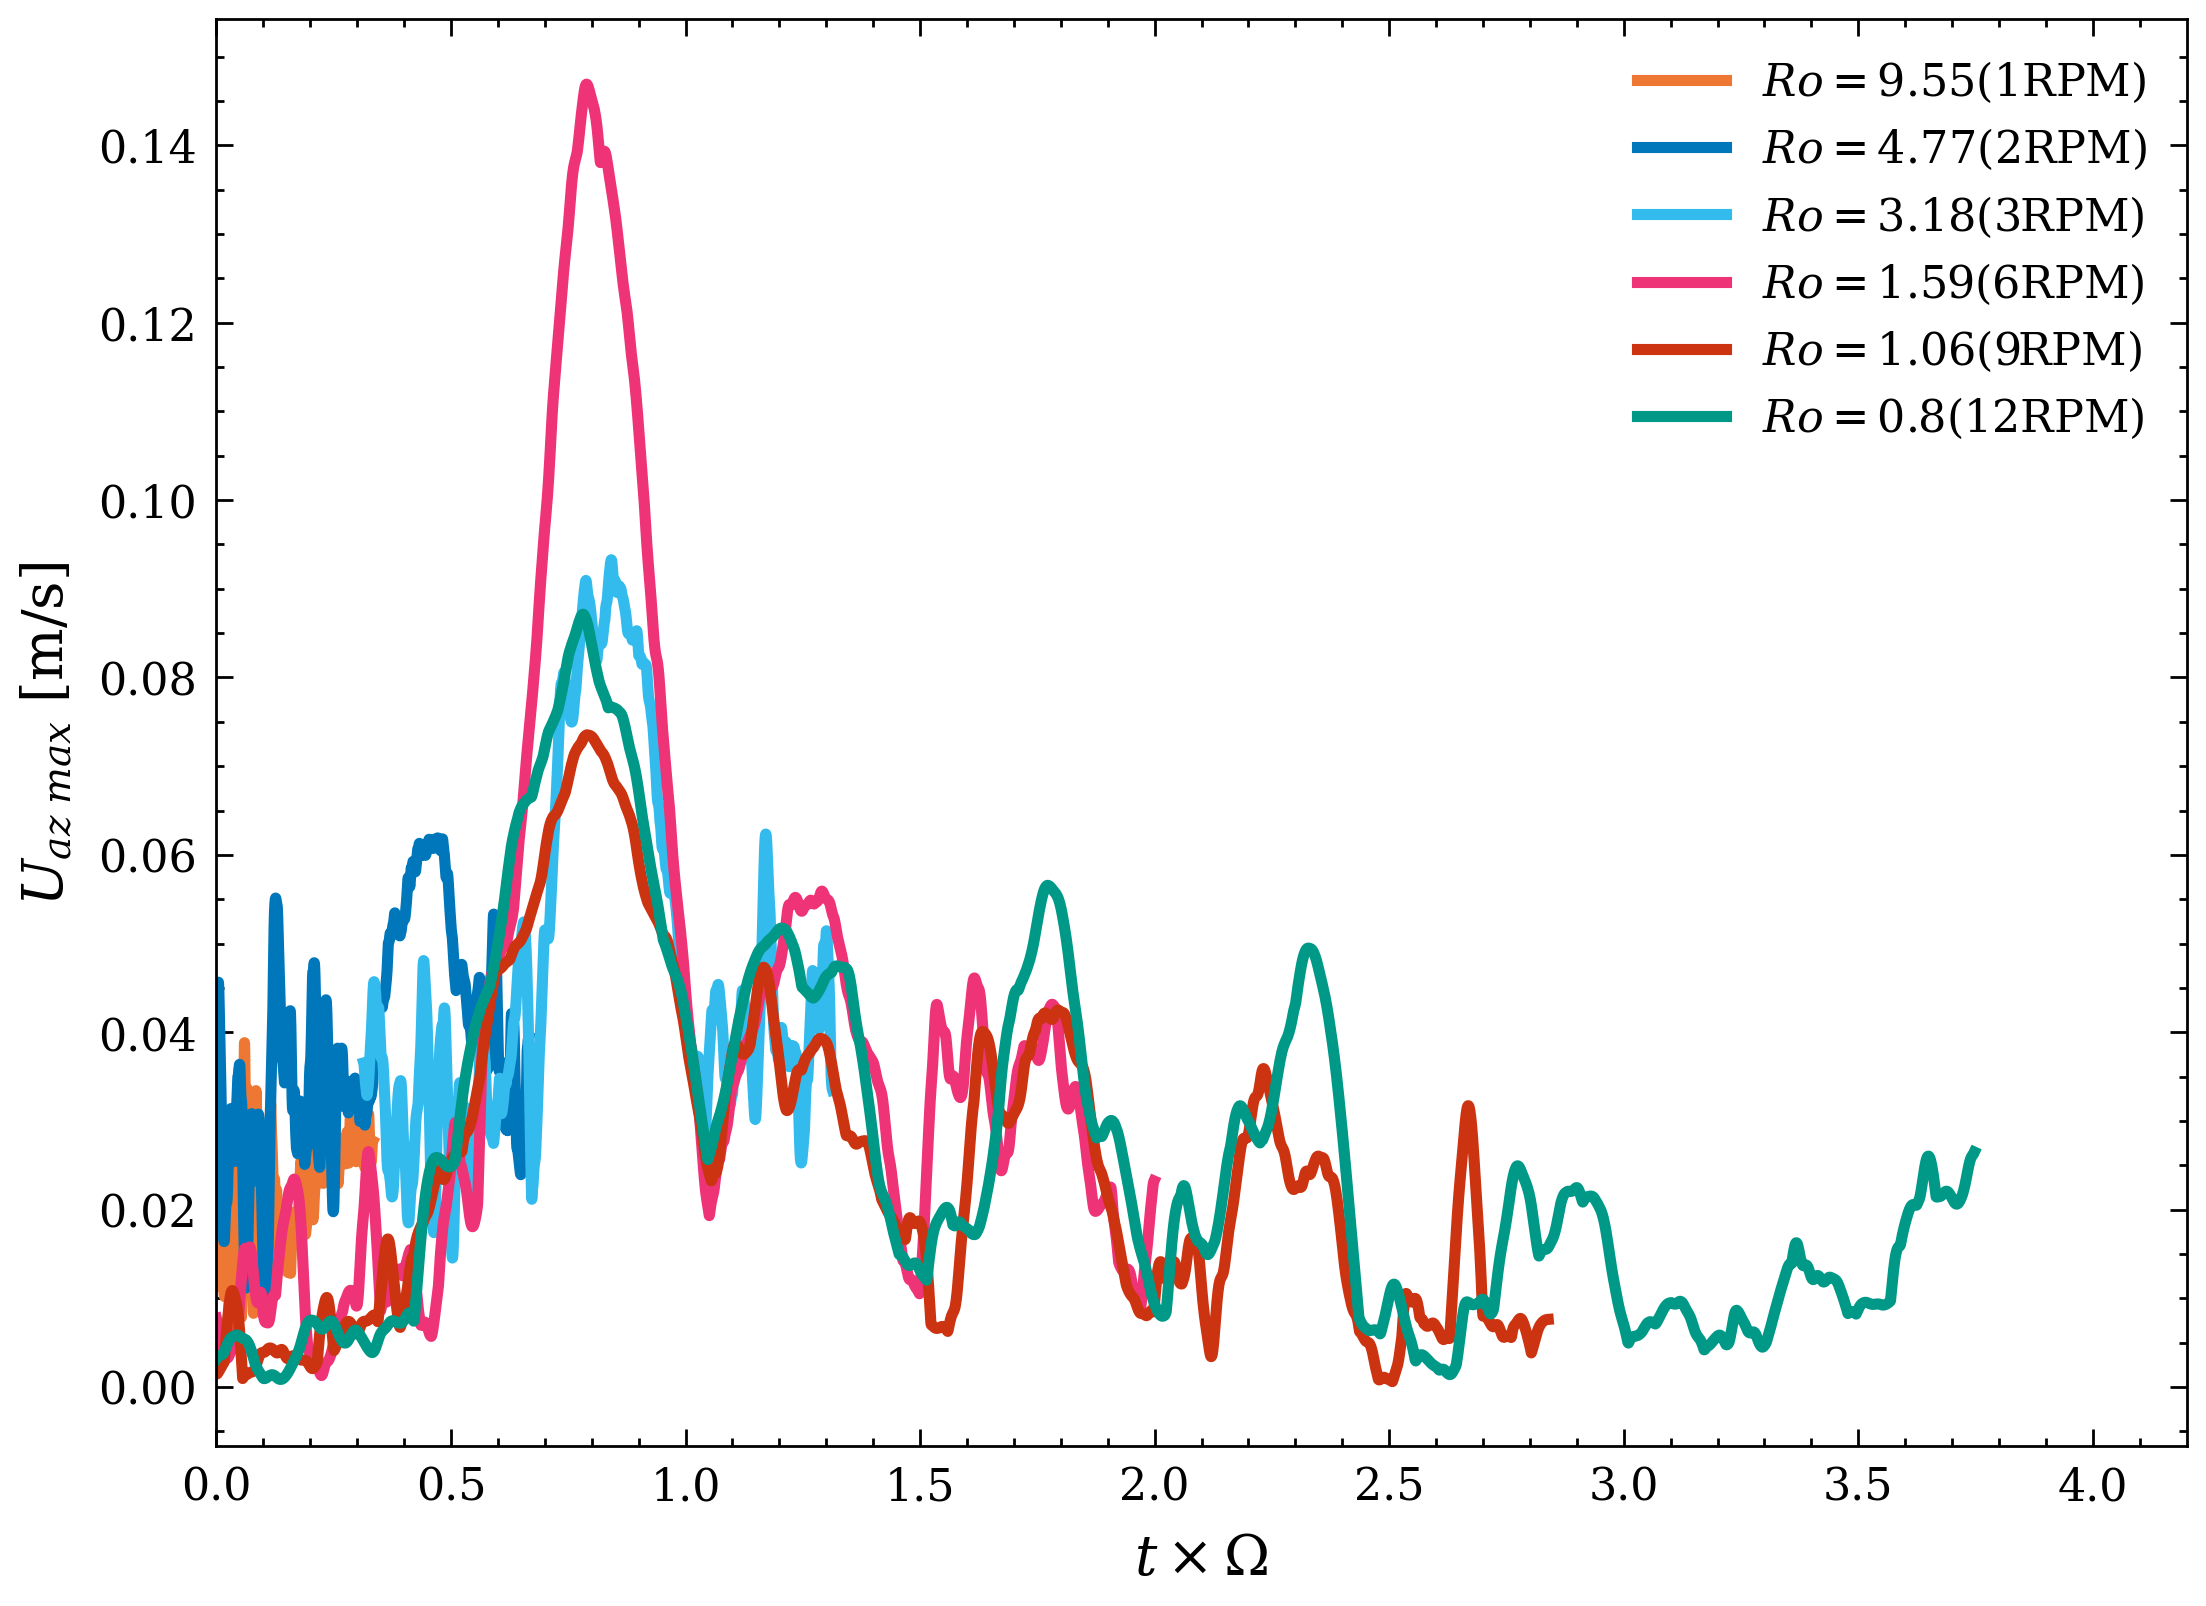

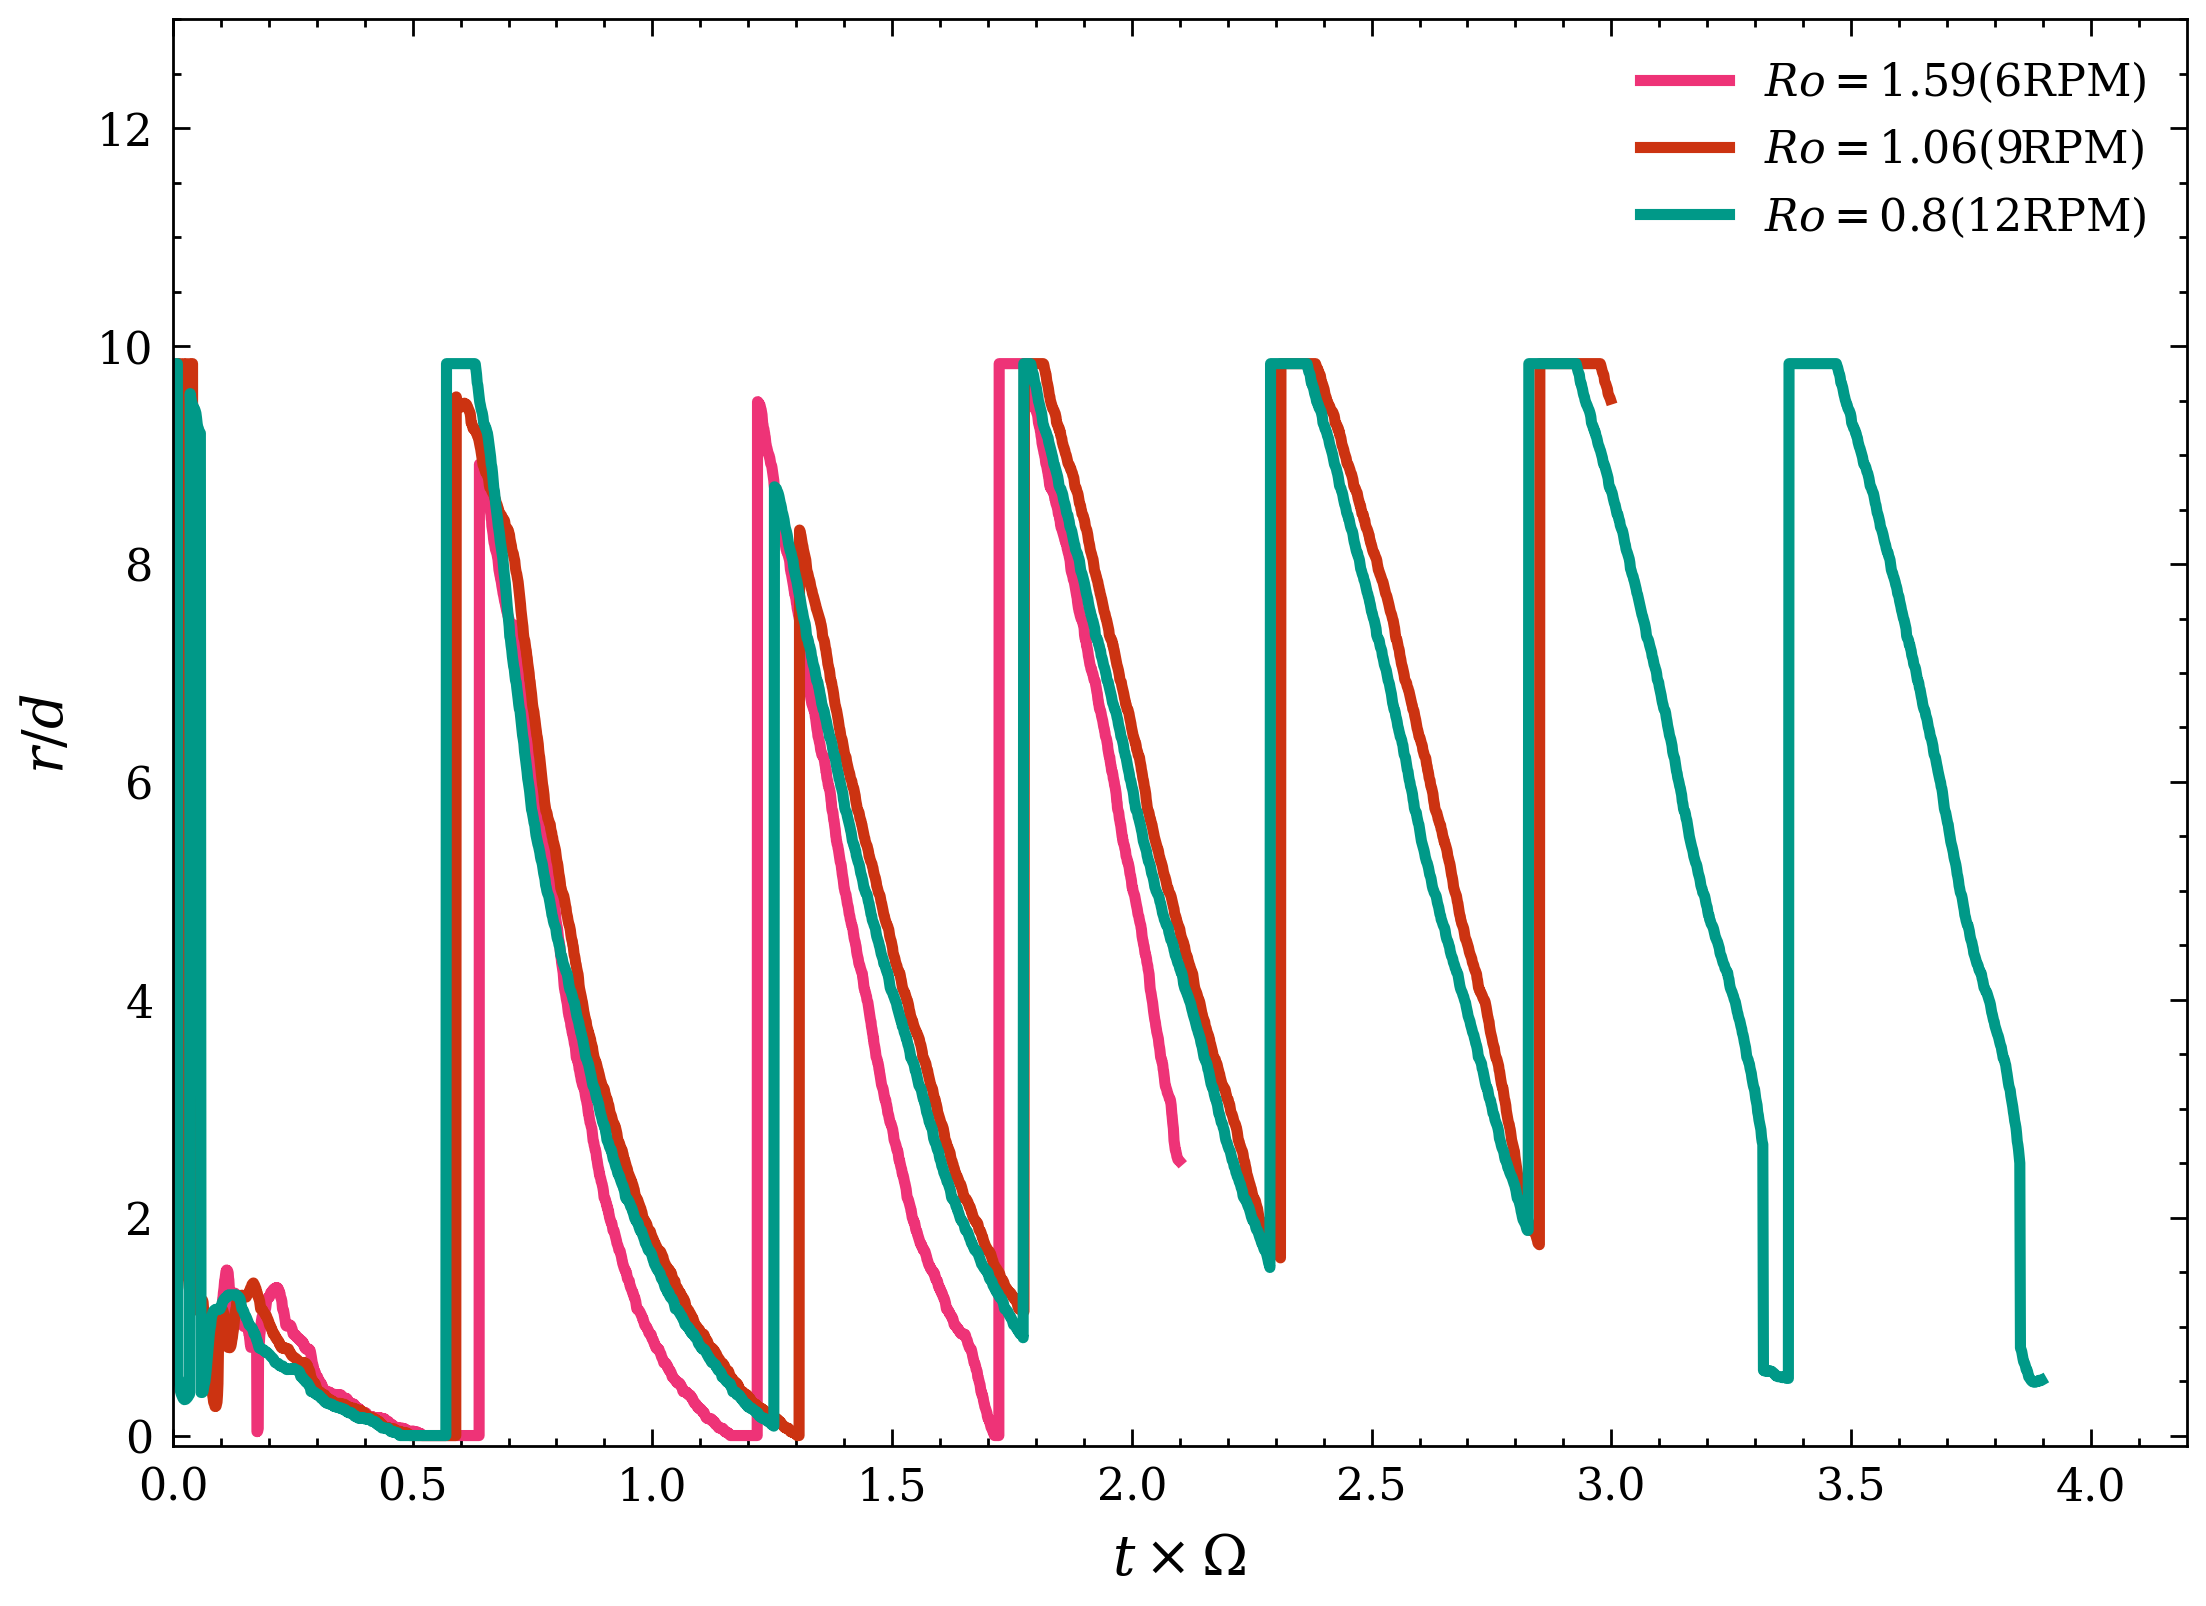

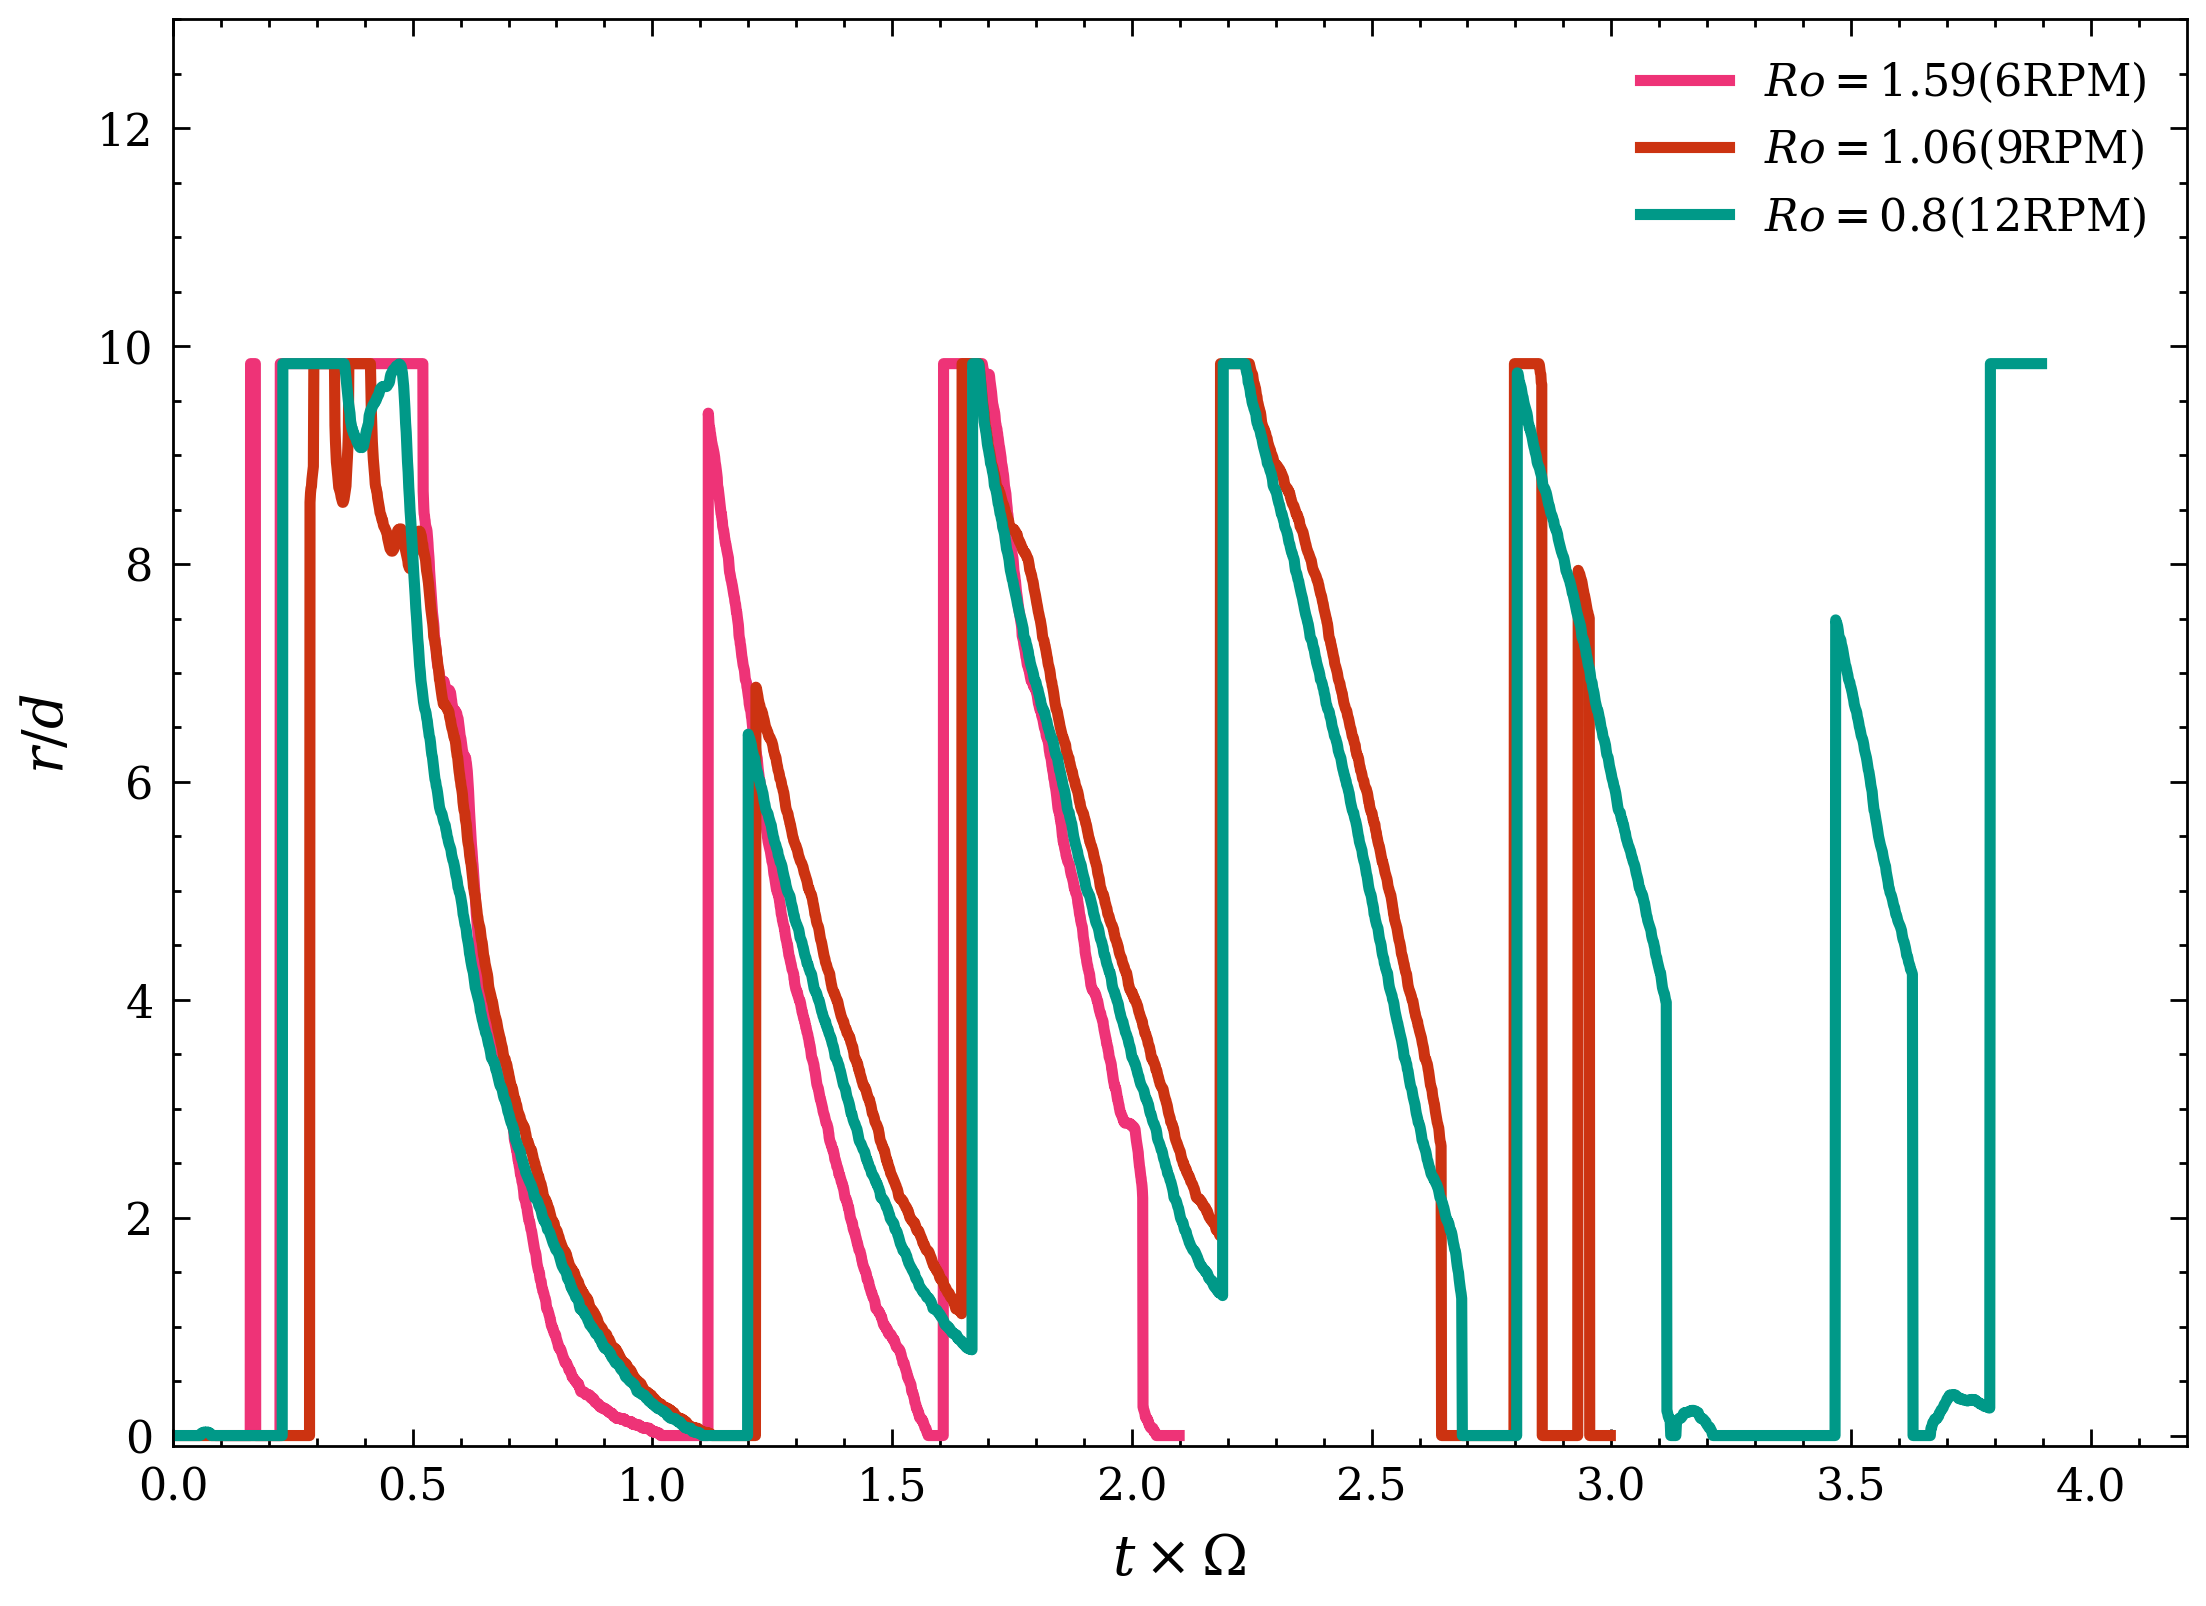

In [10]:
rate = np.zeros(7)
for i in range(len(rpms)):
    rate[i] = rpms[i]/60



f6, ax7 = plt.subplots()
# plt.suptitle("Radial Velocity Graphs")
ax7.plot(time*rate[0], U_r_Mean[0,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[0])}$(1RPM)' )
ax7.plot(time*rate[1], U_r_Mean[1,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[1])}$(2RPM)' )
ax7.plot(time*rate[2], -U_r_Mean[2,:],    label = fr'$Ro = {oj.Ro(0.1, rpms[2])}$(3RPM)' )
ax7.plot(time*rate[3], U_r_Mean[3,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[3])}$(6RPM)' )
ax7.plot(time*rate[4], U_r_Mean[4,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[4])}$(9RPM)' )
ax7.plot(time*rate[5]-0.1, U_r_Mean[5,:], label = fr'$Ro = {oj.Ro(0.1, rpms[5])}$(12RPM)')
ax7.legend(fontsize=8)
# ax7.set_title(r"$U_{r}$ Mean/time")
ax7.set_xlabel(r"$t\times\Omega$")
ax7.set_ylabel(r"$\bar{U}_{r}$ [m/s]")
ax7.set_xlim(0, 4.2)

f7, ax8 = plt.subplots()
# plt.suptitle("Azimuthal Velocity Graphs")
ax8.plot(time*rate[0], U_az_Mean[0,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[0])}$(1RPM)' )
ax8.plot(time*rate[1], U_az_Mean[1,:]*0.5, label = fr'$Ro = {oj.Ro(0.1, rpms[1])}$(2RPM)' )
ax8.plot(time*rate[2], U_az_Mean[2,:]*0.5, label = fr'$Ro = {oj.Ro(0.1, rpms[2])}$(3RPM)' )
ax8.plot(time*rate[3], U_az_Mean[3,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[3])}$(6RPM)' )
ax8.plot(time*rate[4], U_az_Mean[4,:],     label = fr'$Ro = {oj.Ro(0.1, rpms[4])}$(9RPM)' )
ax8.plot(time*rate[5]-0.1, U_az_Mean[5,:], label = fr'$Ro = {oj.Ro(0.1, rpms[5])}$(12RPM)')
ax8.legend(fontsize=8)
# ax8.set_title(r"$U_{az}$ Mean/time")
ax8.set_xlabel(r"$t\times\Omega$")
ax8.set_ylabel(r"$\bar{U}_{az}$ [m/s]")
ax8.set_xlim(0, 4.2)


f9, ax10 = plt.subplots()
# plt.suptitle("Radial Velocity Graphs")
ax10.plot(time*rate[0], U_r_Peak[0,:]*0.1/0.16, label = fr'$Ro = {oj.Ro(0.1, rpms[0])}$(1RPM)' )
ax10.plot(time*rate[1], U_r_Peak[1,:]*0.1/0.16, label = fr'$Ro = {oj.Ro(0.1, rpms[1])}$(2RPM)' )
ax10.plot(time*rate[2], U_r_Peak[2,:]*0.1/0.16, label = fr'$Ro = {oj.Ro(0.1, rpms[2])}$(3RPM)' )
ax10.plot(time*rate[3], U_r_Peak[3,:],          label = fr'$Ro = {oj.Ro(0.1, rpms[3])}$(6RPM)' )
ax10.plot(time*rate[4]-0.124, U_r_Peak[4,:],    label = fr'$Ro = {oj.Ro(0.1, rpms[4])}$(9RPM)' )
ax10.plot(time*rate[5]-0.221, U_r_Peak[5,:],    label = fr'$Ro = {oj.Ro(0.1, rpms[5])}$(12RPM)')
ax10.legend(fontsize=8)
# ax10.set_title(r"$U_{r}$ Peak/time")
ax10.set_xlabel(r"$t\times\Omega$")
ax10.set_ylabel(r"$U_{r~max} [m/s]$")
ax10.set_xlim(0, 4.2)

f10, ax11 = plt.subplots()
# plt.suptitle("Azimuthal Velocity Graphs")
ax11.plot(time*rate[0], U_az_Peak[0,:],       label = fr'$Ro = {oj.Ro(0.1, rpms[0])}$(1RPM)' )
ax11.plot(time*rate[1], U_az_Peak[1,:],       label = fr'$Ro = {oj.Ro(0.1, rpms[1])}$(2RPM)' )
ax11.plot(time*rate[2]+0.314, U_az_Peak[2,:], label = fr'$Ro = {oj.Ro(0.1, rpms[2])}$(3RPM)' )
ax11.plot(time*rate[3], U_az_Peak[3,:],       label = fr'$Ro = {oj.Ro(0.1, rpms[3])}$(6RPM)' )
ax11.plot(time*rate[4]-0.159, U_az_Peak[4,:], label = fr'$Ro = {oj.Ro(0.1, rpms[4])}$(9RPM)' )
ax11.plot(time*rate[5]-0.25, U_az_Peak[5,:],  label = fr'$Ro = {oj.Ro(0.1, rpms[5])}$(12RPM)')
# ax11.set_title(r"$U_{az}$ Peak/time")
ax11.set_xlabel(r"$t\times\Omega$")
ax11.set_ylabel(r"$U_{az~max}$ [m/s]")
ax11.legend(fontsize=8)
ax11.set_xlim(0, 4.2)

fig, ax1 = plt.subplots()
# ax1.plot(time*rate[0], radial_Positionr[0,:], label = '1RPM')
# ax1.plot(time*rate[1], radial_Positionr[1,:], label = '2RPM')
# ax1.plot(time*rate[2], radial_Positionr[2,:], label = '3RPM')
ax1.plot(time*rate[3]+0.1, radial_Positionr[3,:]/inds.shape*13, label = fr'$Ro = {oj.Ro(0.1, rpms[3])}$(6RPM)', color = '#EE3377')
ax1.plot(time*rate[4], radial_Positionr[4,:]/inds.shape*13,     label = fr'$Ro = {oj.Ro(0.1, rpms[4])}$(9RPM)', color = '#CC3311')
ax1.plot(time*rate[5]-0.1, radial_Positionr[5,:]/inds.shape*13, label = fr'$Ro = {oj.Ro(0.1, rpms[5])}$(12RPM)', color = '#009988')
# ax1.set_title(r"$U_{az}$ Peak/time")
ax1.set_xlabel(r"$t\times\Omega$")
ax1.set_ylabel(r"$r/d$")
ax1.legend(fontsize=8)
ax1.set_xlim(0, 4.2)
ax1.set_ylim(-0.1, 13)

fig, ax2 = plt.subplots()
# ax2.plot(time*rate[0], radial_Positionaz[0,:], label = '1RPM')
# ax2.plot(time*rate[1], radial_Positionaz[1,:], label = '2RPM')
# ax2.plot(time*rate[2], radial_Positionaz[2,:], label = '3RPM')
ax2.plot(time*rate[3]+0.1, radial_Positionaz[3,:]/inds.shape*13, label = fr'$Ro = {oj.Ro(0.1, rpms[3])}$(6RPM)', color = '#EE3377')
ax2.plot(time*rate[4], radial_Positionaz[4,:]/inds.shape*13,     label = fr'$Ro = {oj.Ro(0.1, rpms[4])}$(9RPM)', color = '#CC3311')
ax2.plot(time*rate[5]-0.1, radial_Positionaz[5,:]/inds.shape*13, label = fr'$Ro = {oj.Ro(0.1, rpms[5])}$(12RPM)', color = '#009988')
# ax2.set_title(r"$U_{az}$ Peak/time")
ax2.set_xlabel(r"$t\times\Omega$")
ax2.set_ylabel(r"$r/d$")
ax2.legend(fontsize=8)
ax2.set_xlim(0, 4.2)
ax2.set_ylim(-0.1, 13)

#EE3377
#CC3311
#009988